# Setup Dependencies

In [7]:
pip install -r requirements.txt

  Using cached gunicorn-23.0.0-py3-none-any.whl.metadata (4.4 kB)
Using cached gunicorn-23.0.0-py3-none-any.whl (85 kB)
Note: you may need to restart the kernel to use updated packages.


In [8]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import requests
import json

In [9]:
import folium
import requests
import json

# URL of the GeoJSON file
url = "https://raw.githubusercontent.com/leakyMirror/map-of-europe/master/GeoJSON/europe.geojson"

# Fetch the GeoJSON data
response = requests.get(url)
geojson_data = json.loads(response.text)

# Create a map centered on Europe
m = folium.Map(location=[50, 10], zoom_start=4)

# Add the GeoJSON data to the map
folium.GeoJson(
    geojson_data,
    style_function=lambda feature: {
        'fillColor': '#ffff00',
        'color': 'black',
        'weight': 2,
        'fillOpacity': 0.5,
    }
).add_to(m)

# Save the map to an HTML file
m.save('europe_map.html')

print("Map saved as europe_map.html")

Map saved as europe_map.html


In [10]:
price_and_purity_excel_file = './data/raw/8.1_Prices_and_purities_of_drugs.xlsx'
seizures_excel_file = './data/raw/7.1_Drug_seizures_2019-2023.xlsx'


prices_output_dir = './data/clean/prices'
purities_output_dir = './data/clean/purities'
seizures_output_dir = './data/clean/seizures'

In [11]:
sheets = pd.read_excel(price_and_purity_excel_file, sheet_name=None)
for key in sheets.keys():
    print(key)
sheets = pd.read_excel(seizures_excel_file, sheet_name=None)
for key in sheets.keys():
    print(key)

Prices in USD
Purities
Seizures


# Read In Data


## Prices

In [12]:
drug_prices_df = pd.read_excel(price_and_purity_excel_file, 
                   sheet_name='Prices in USD',
                   header=1,
                   usecols="A:L"
                   )
drug_prices_df.head()

,Region,SubRegion,Country/Territory,DrugGroup,Drug,Specify,LevelOfSale,Year,Typical_USD,Minimum_USD,Maximum_USD,Unit
0,Asia,East and South-East Asia,"China, Macao SAR",“Ecstasy”-type substances,“Ecstasy”-type substances,NaN,Retail,2023,NaN,NaN,24.807740,Tablets
1,Asia,East and South-East Asia,"China, Macao SAR",“Ecstasy”-type substances,“Ecstasy”-type substances,NaN,Retail,2020,NaN,NaN,250.563768,Tablets
2,Africa,Southern Africa,South Africa,“Ecstasy”-type substances,“Ecstasy”-type substances,NaN,Retail,2023,NaN,4.564721,5.516792,Tablets
3,Europe,South-Eastern Europe,Bosnia and Herzegovina,“Ecstasy”-type substances,“Ecstasy”-type substances,NaN,Retail,2023,NaN,5.405405,10.810811,Tablets
4,Europe,South-Eastern Europe,Serbia,“Ecstasy”-type substances,“Ecstasy”-type substances,NaN,Retail,2022,NaN,8.429926,10.537408,Units


In [13]:
drug_prices_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4693 entries, 0 to 4692
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Region             4693 non-null   object 
 1   SubRegion          4693 non-null   object 
 2   Country/Territory  4693 non-null   object 
 3   DrugGroup          4693 non-null   object 
 4   Drug               4693 non-null   object 
 5   Specify            221 non-null    object 
 6   LevelOfSale        4693 non-null   object 
 7   Year               4693 non-null   int64  
 8   Typical_USD        3825 non-null   float64
 9   Minimum_USD        3472 non-null   float64
 10  Maximum_USD        3501 non-null   float64
 11  Unit               4600 non-null   object 
dtypes: float64(3), int64(1), object(8)
memory usage: 440.1+ KB


## Purities

In [14]:
drug_purity_df = pd.read_excel(price_and_purity_excel_file, 
                   sheet_name='Purities',
                   header=1,
                   usecols="A:L"
                   )
drug_purity_df.head()

,Region,SubRegion,Country/Territory,LevelOfSale,DrugGroup,Drug,Specify,Year,Typical,Minimum,Maximum,Measurement
0,Africa,East Africa,Kenya,Wholesale,Opioids,Heroin,NaN,2020,39.0,35.0,42.0,% (percent)
1,Africa,East Africa,Kenya,Retail,Cocaine-type,Cocaine salts,NaN,2019,10.0,5.0,15.0,% (percent)
2,Africa,East Africa,Kenya,Retail,Opioids,Heroin,Brown,2019,10.0,5.0,15.0,% (percent)
3,Africa,East Africa,Kenya,Wholesale,Cocaine-type,Cocaine salts,NaN,2019,15.0,25.0,30.0,% (percent)
4,Africa,East Africa,Kenya,Wholesale,Opioids,Heroin,Brown,2019,25.0,30.0,60.0,% (percent)


In [15]:
drug_purity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1751 entries, 0 to 1750
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Region             1751 non-null   object 
 1   SubRegion          1751 non-null   object 
 2   Country/Territory  1751 non-null   object 
 3   LevelOfSale        1751 non-null   object 
 4   DrugGroup          1751 non-null   object 
 5   Drug               1751 non-null   object 
 6   Specify            38 non-null     object 
 7   Year               1751 non-null   int64  
 8   Typical            1543 non-null   float64
 9   Minimum            1475 non-null   float64
 10  Maximum            1494 non-null   float64
 11  Measurement        1682 non-null   object 
dtypes: float64(3), int64(1), object(8)
memory usage: 164.3+ KB


## Seizures

In [16]:
drug_seizures_df = pd.read_excel(seizures_excel_file, 
                   sheet_name='Seizures',
                   header=1,
                   usecols="A:I"
                   )
drug_seizures_df.head()

,Region,SubRegion,Country,DrugGroup,DrugSubGroup,DrugName,Reference year,Kilograms,msCode
0,Africa,East Africa,Comoros,Any other drugs/substances,Other miscellaneous,Other drugs/substances,2023,45.0,COM
1,Africa,East Africa,Comoros,Cannabis-type drugs (excluding synthetic canna...,Cannabis herb (marijuana),Cannabis herb (marijuana),2023,2263.0,COM
2,Africa,East Africa,Comoros,Cannabis-type drugs (excluding synthetic canna...,Cannabis resin (hashish),Cannabis resin (hashish),2023,57.5,COM
3,Africa,East Africa,Comoros,NPS,Synthetic cannabinoids (Spice),Synthetic cannabinoids (“Spice”),2023,10.0,COM
4,Africa,East Africa,Comoros,Opioids,Opiates,Heroin,2023,0.5,COM


In [17]:
drug_seizures_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11274 entries, 0 to 11273
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Region          11274 non-null  object 
 1   SubRegion       11274 non-null  object 
 2   Country         11274 non-null  object 
 3   DrugGroup       11274 non-null  object 
 4   DrugSubGroup    11274 non-null  object 
 5   DrugName        11274 non-null  object 
 6   Reference year  11274 non-null  int64  
 7   Kilograms       11198 non-null  float64
 8   msCode          11274 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 792.8+ KB


# Clean and Filter Data

## Unify Column Names

In [18]:
drug_prices_df = drug_prices_df.rename(columns={'Country/Territory':'Country'})
drug_purity_df = drug_purity_df.rename(columns={'Country/Territory':'Country'})
drug_seizures_df = drug_seizures_df.rename(columns={'Reference year':'Year'})

## Filter Region to Europe

In [19]:
region = 'Europe'
drug_seizures_df = drug_seizures_df[drug_seizures_df['Region'] == region].reset_index(drop=True)
drug_prices_df = drug_prices_df[drug_prices_df['Region'] == region].reset_index(drop=True)
drug_purity_df = drug_purity_df[drug_purity_df['Region'] == region].reset_index(drop=True)

## Save Filtered Europe Data Back to Original Files

In [20]:
from openpyxl import load_workbook
import pandas as pd
# Save drug prices to Prices sheet
with pd.ExcelWriter(price_and_purity_excel_file, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    drug_prices_df.to_excel(writer, sheet_name='Prices in USD', index=False)
    print("✓ Saved Europe-filtered prices to 'Prices in USD' sheet")

# Save drug purity to Purities sheet
with pd.ExcelWriter(price_and_purity_excel_file, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    drug_purity_df.to_excel(writer, sheet_name='Purities', index=False)
    print("✓ Saved Europe-filtered purity to 'Purities' sheet")

# Save drug seizures to Seizures sheet
with pd.ExcelWriter(seizures_excel_file, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    drug_seizures_df.to_excel(writer, sheet_name='Seizures', index=False)
    print("✓ Saved Europe-filtered seizures to 'Seizures' sheet")

print("\nAll data successfully saved back to original files with Europe-only records!")

✓ Saved Europe-filtered prices to 'Prices in USD' sheet
✓ Saved Europe-filtered purity to 'Purities' sheet
✓ Saved Europe-filtered seizures to 'Seizures' sheet

All data successfully saved back to original files with Europe-only records!


## Classify Substances
get rid of inconsistent drug grouping, classification will also reduce to a smaller/broader selection of drugs/substances.

In [15]:
drug_prices_df['DrugGroup'].unique()

array(['“Ecstasy”-type substances', 'Amphetamine-type stimulants',
       'Amphetamine-type stimulants (excluding “ecstasy”)',
       'Any other drugs/substances', 'ATS', 'Cannabis-type',
       'Cannabis-type drugs',
       'Cannabis-type drugs (excluding synthetic cannabinoids)',
       'Cocaine-type', 'Cocaine-type drugs', 'Hallucinogens', 'NPS',
       'Opioids', 'Precursors',
       'Sedatives and tranquilizers (please specify)',
       'Sedatives and Tranquillizers',
       'Substances not under international control'], dtype=object)

In [16]:
drug_purity_df['DrugGroup'].unique()

array(['“Ecstasy”-type substances', 'Amphetamine-type stimulants',
       'Cannabis-type drugs', 'Cocaine-type drugs', 'Hallucinogens',
       'Opioids', 'Cannabis-type', 'Cocaine-type', 'ATS',
       'Sedatives and tranquilizers (please specify)',
       'Sedatives and Tranquillizers'], dtype=object)

In [17]:
drug_seizures_df['DrugGroup'].unique()

array(['“Ecstasy”-type substances',
       'Amphetamine-type stimulants (excluding “ecstasy”)',
       'Cannabis-type drugs (excluding synthetic cannabinoids)',
       'Cocaine-type', 'Hallucinogens', 'Opioids',
       'Sedatives and tranquillizers', 'NPS', 'Precursors',
       'Any other drugs/substances', 'Solvents and Inhalants'],
      dtype=object)

In [18]:
def classify_substances(x: str):
    if x in ['Amphetamine-type stimulants', 
             'Amphetamine-type stimulants (excluding "ecstasy")', 
             'ATS']:
        return 'Amphetamines'
    
    elif x in ['Cannabis-type', 
               'Cannabis-type drugs', 
               'Cannabis-type drugs (excluding synthetic cannabinoids)']:
        return 'Cannabis'
    
    elif x in ['Cocaine-type', 'Cocaine-type drugs']:
        return 'Cocaine'
    
    elif x in ['Sedatives and Tranquillizers', 
               'Sedatives and tranquilizers (please specify)', 
               'Sedatives and tranquillizers']:
        return 'Tranquillizers and Sedatives'
    
    elif x == '"Ecstasy"-type substances':
        return 'Ecstasy'
    
    elif x == 'Opioids':
        return 'Opioids'
    
    elif x == 'Hallucinogens':
        return 'Hallucinogens'
    
    elif x in ['NPS', 'Precursors', 'Any other drugs/substances', 
               'Substances not under international control',
               'Solvents and Inhalants']:
        return 'Other'
    
    else:
        return 'Other'

In [19]:
drug_seizures_df['Substance'] = drug_seizures_df['DrugGroup'].apply(lambda x: classify_substances(x))
drug_prices_df['Substance'] = drug_prices_df['DrugGroup'].apply(lambda x: classify_substances(x))
drug_purity_df['Substance'] = drug_purity_df['DrugGroup'].apply(lambda x: classify_substances(x))

## Unify Country Names
Visualization later requires unique names for countries

In [20]:
url = "https://raw.githubusercontent.com/leakyMirror/map-of-europe/master/GeoJSON/europe.geojson"
response = requests.get(url)
europe_gdf = gpd.read_file(response.content)

df_countries = set(drug_prices_df['Country'].unique())
geojson_countries = set(europe_gdf['NAME'])
missing_in_geojson = df_countries - geojson_countries

print("Countries in your dataframe not found in GeoJSON:")
print(missing_in_geojson)

missing_in_df = geojson_countries - df_countries
print("\nCountries in GeoJSON not found in your dataframe:")
print(missing_in_df)

print("\nAll country names in GeoJSON:")
print(sorted(geojson_countries))

Countries in your dataframe not found in GeoJSON:
{'Gibraltar', 'Russian Federation', 'North Macedonia', 'Türkiye', 'Czechia'}

Countries in GeoJSON not found in your dataframe:
{'Israel', 'Russia', 'Czech Republic', 'Faroe Islands', 'Turkey', 'Holy See (Vatican City)', 'Azerbaijan', 'Monaco', 'Armenia', 'San Marino', 'Georgia', 'The former Yugoslav Republic of Macedonia', 'Switzerland'}

All country names in GeoJSON:
['Albania', 'Andorra', 'Armenia', 'Austria', 'Azerbaijan', 'Belarus', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Estonia', 'Faroe Islands', 'Finland', 'France', 'Georgia', 'Germany', 'Greece', 'Holy See (Vatican City)', 'Hungary', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Latvia', 'Liechtenstein', 'Lithuania', 'Luxembourg', 'Malta', 'Monaco', 'Montenegro', 'Netherlands', 'Norway', 'Poland', 'Portugal', 'Republic of Moldova', 'Romania', 'Russia', 'San Marino', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Swi

In [21]:
# {'Czech Republic', 'The former Yugoslav Republic of Macedonia', 'Russia', 'Israel', 'Faroe Islands', 'Armenia', 'Holy See (Vatican City)', 'Monaco', 'San Marino', 'Switzerland', 'Turkey', 'Azerbaijan', 'Norway', 'Georgia'}
# {'Russian Federation', 'Czechia', 'Gibraltar', 'Türkiye', 'North Macedonia'}
def rename_countries(x:str):
    if x in 'Russian Federation':
        return 'Russia'
    elif x in 'North Macedonia':
        return 'The former Yugoslav Republic of Macedonia'
    elif x in 'Czechia':
        return 'Czech Republic'
    elif x in 'Türkiye':
        return 'Turkey'
    else:
        return x

In [22]:
drug_seizures_df['Country'] = drug_seizures_df['Country'].apply(lambda x:rename_countries(x))
drug_prices_df['Country'] = drug_prices_df['Country'].apply(lambda x:rename_countries(x))
drug_purity_df['Country'] = drug_purity_df['Country'].apply(lambda x:rename_countries(x))

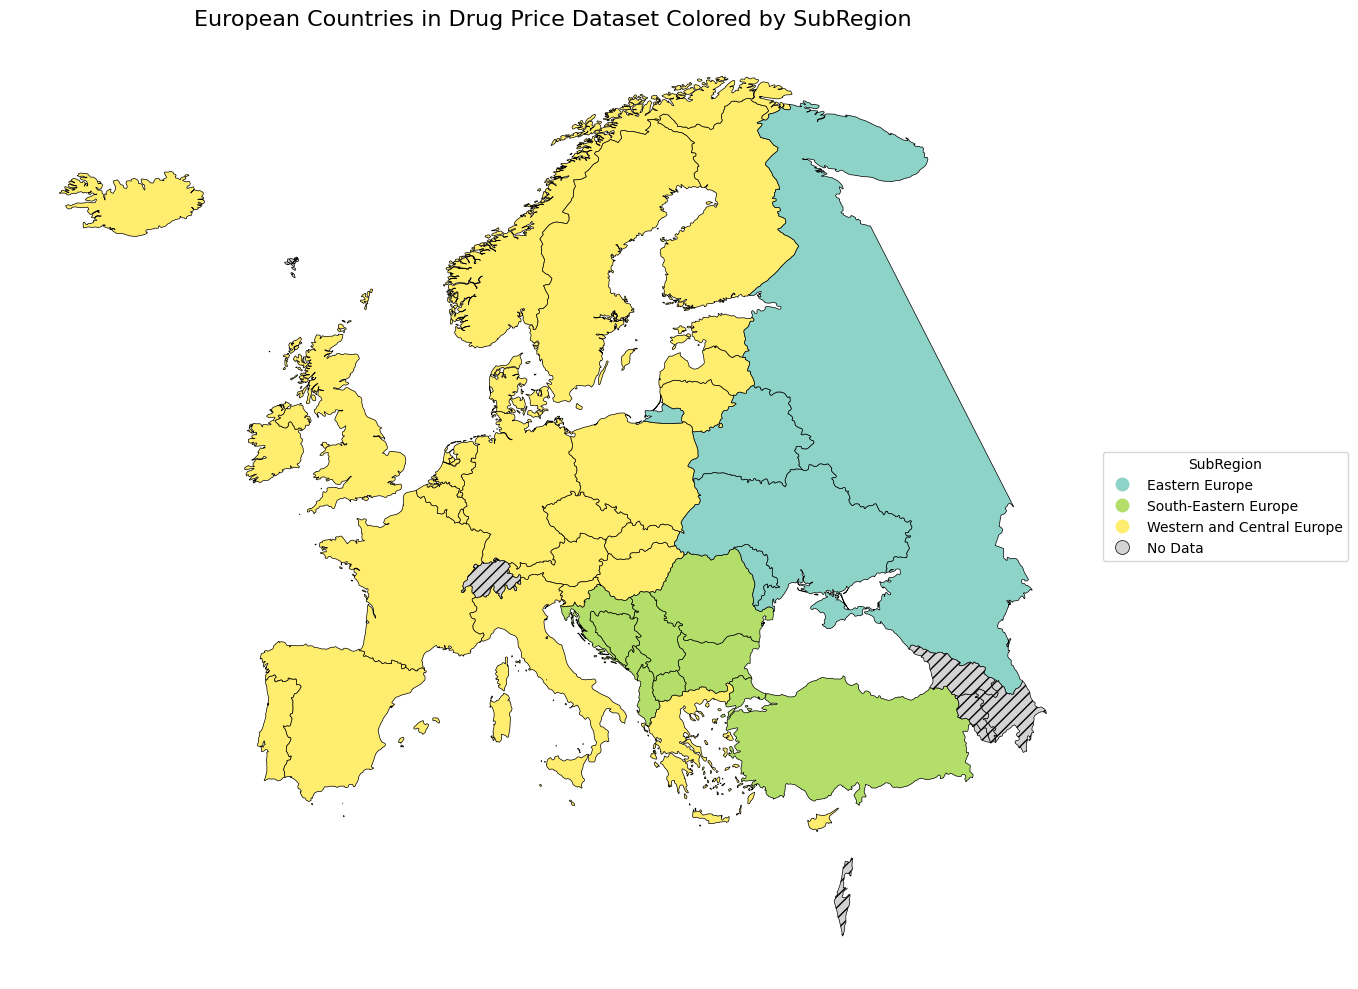

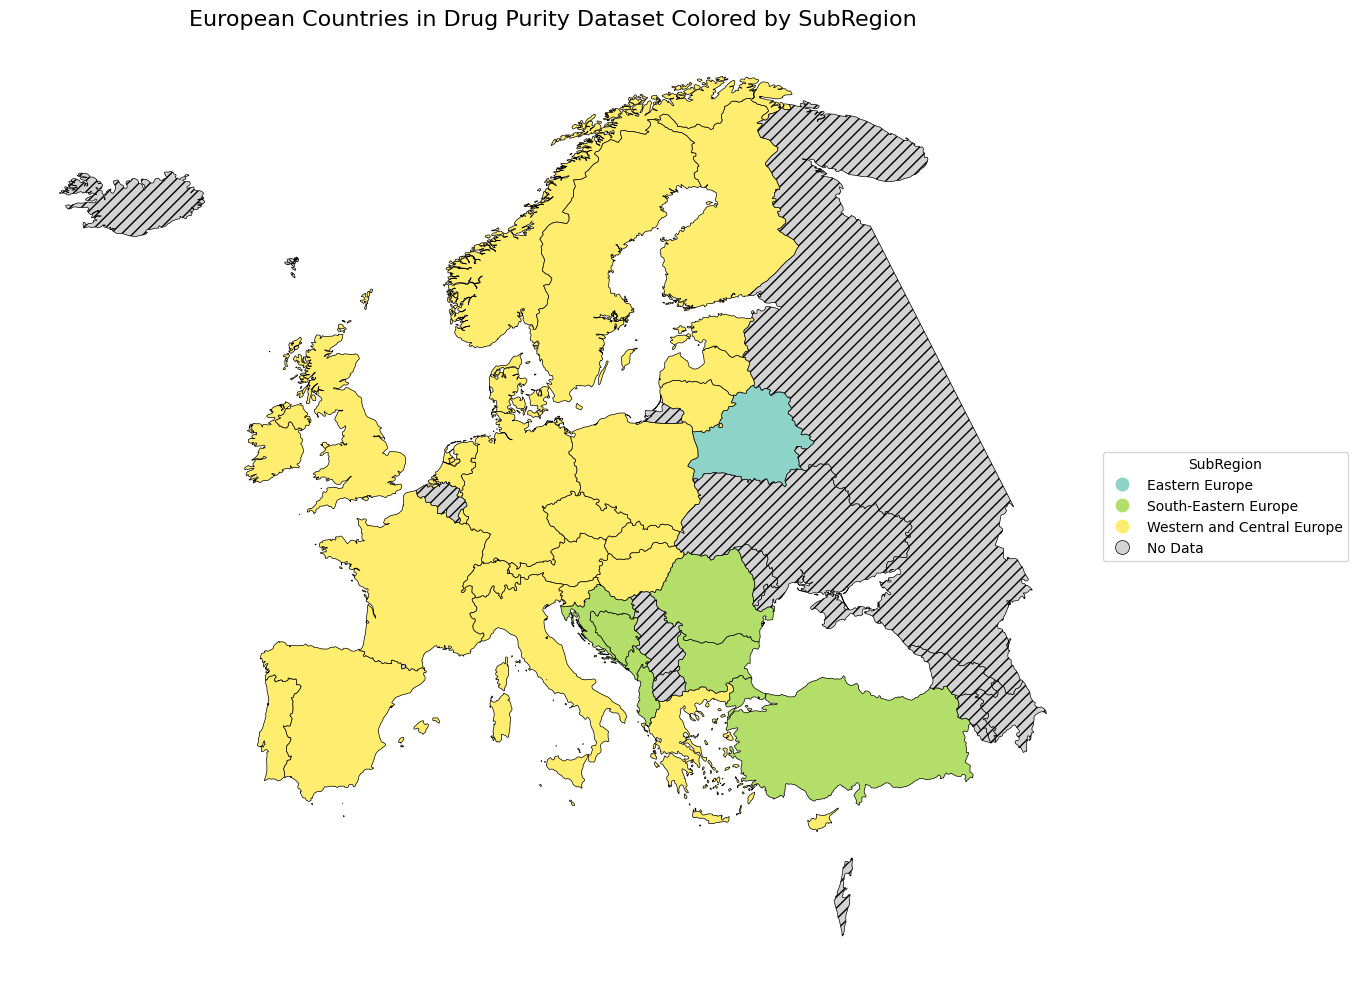

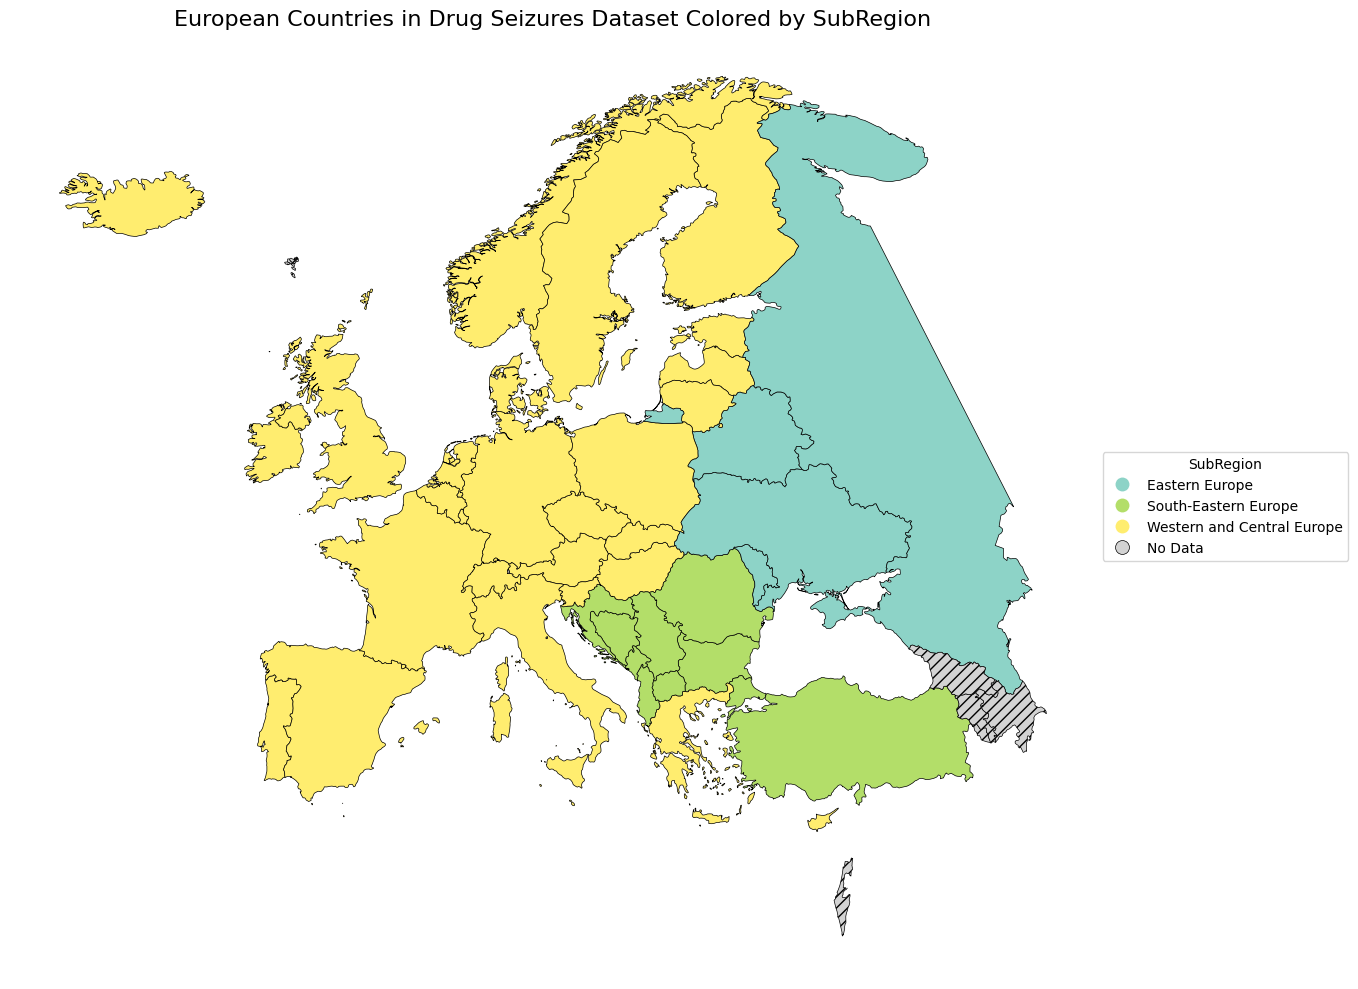

In [23]:
url = "https://raw.githubusercontent.com/leakyMirror/map-of-europe/master/GeoJSON/europe.geojson"
response = requests.get(url)
europe_gdf = gpd.read_file(response.content)

def plot_european(df:pd.DataFrame, title:str):
    subregion_data = df[['Country', 'SubRegion']].drop_duplicates()

    europe_subregions = europe_gdf.merge(subregion_data, how='left', left_on='NAME', right_on='Country')

    fig, ax = plt.subplots(1, 1, figsize=(15, 10))

    cmap = 'Set3'  

    europe_subregions.plot(column='SubRegion', ax=ax, legend=True,
                        legend_kwds={'title': 'SubRegion', 'loc': 'center left', 'bbox_to_anchor': (1, 0.5)},
                        missing_kwds={'color': 'lightgrey', 'edgecolor': 'black', 'hatch': '///', 'label': 'No Data'},
                        cmap=cmap,
                        edgecolor='black', linewidth=0.5)
    
    ax.axis('off')
    ax.set_title(title, fontsize=16)

    plt.tight_layout()
    plt.show()
plot_european(drug_prices_df, 'European Countries in Drug Price Dataset Colored by SubRegion')
plot_european(drug_purity_df, 'European Countries in Drug Purity Dataset Colored by SubRegion')
plot_european(drug_seizures_df, 'European Countries in Drug Seizures Dataset Colored by SubRegion')

Countries in all three datasets:
['Albania', 'Austria', 'Belarus', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Gibraltar', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Montenegro', 'Netherlands', 'Norway', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Turkey', 'United Kingdom']

Total: 34


Countries NOT in all three datasets:
['Andorra', 'Armenia', 'Azerbaijan', 'Belgium', 'Faroe Islands', 'Georgia', 'Holy See (Vatican City)', 'Iceland', 'Israel', 'Liechtenstein', 'Monaco', 'Republic of Moldova', 'Russia', 'San Marino', 'Serbia', 'Switzerland', 'The former Yugoslav Republic of Macedonia', 'Ukraine']

Total: 18


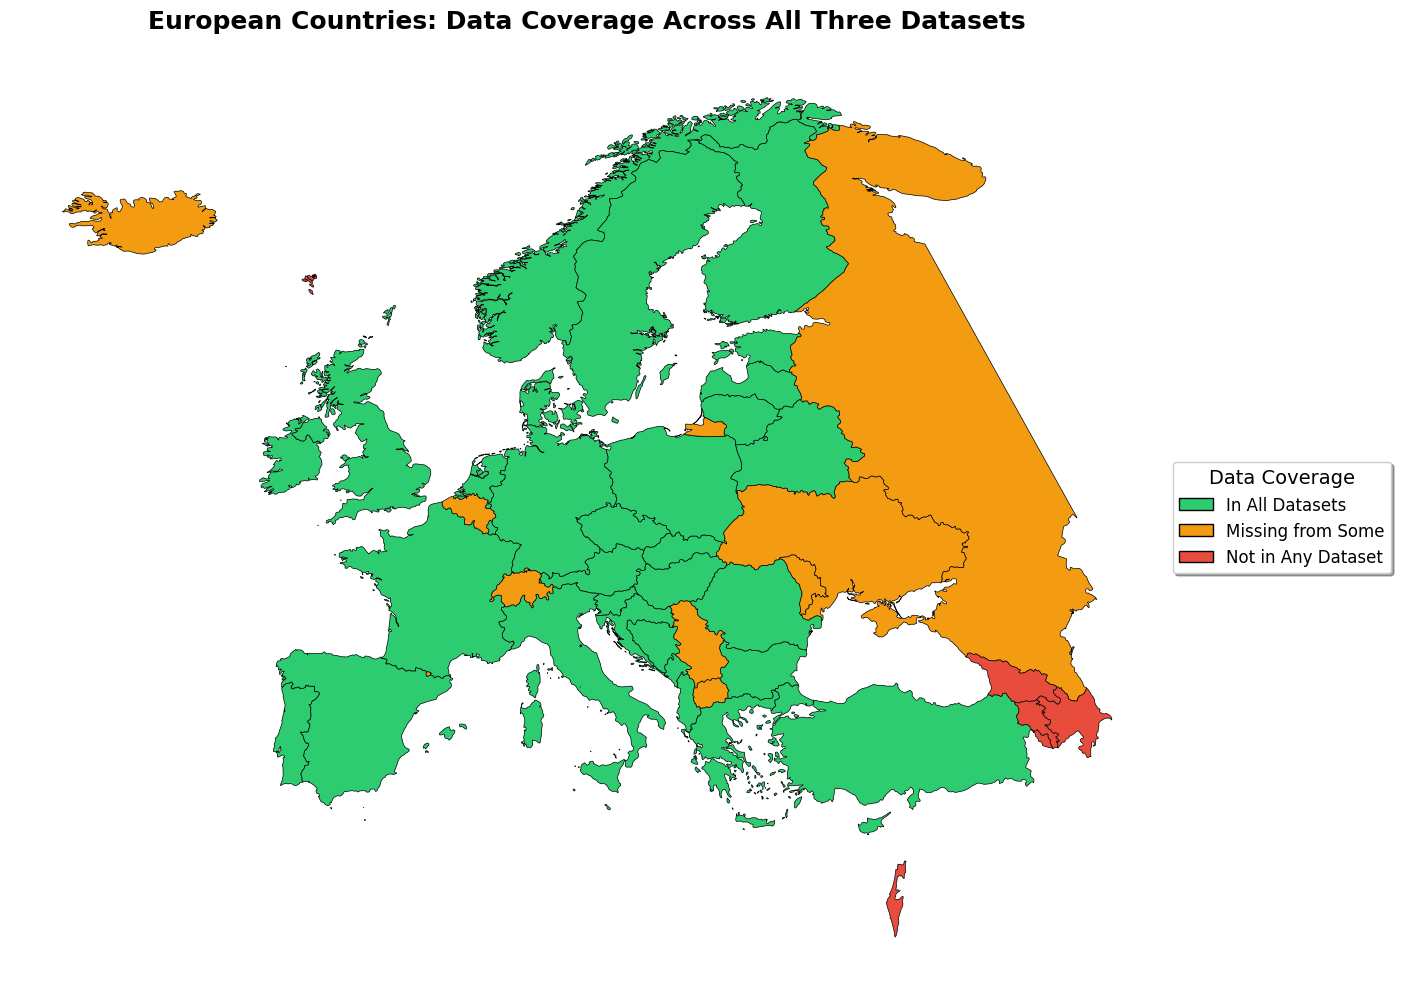


European Countries: Data Coverage Across All Three Datasets Statistics:
Coverage
In All Datasets       33
Missing from Some     10
Not in Any Dataset     8
Name: count, dtype: int64

DETAILED BREAKDOWN:

Prices Dataset:
  Countries present: 43
  Countries missing: 9
  Missing: ['Armenia', 'Azerbaijan', 'Faroe Islands', 'Georgia', 'Holy See (Vatican City)', 'Israel', 'Monaco', 'San Marino', 'Switzerland']

Purity Dataset:
  Countries present: 35
  Countries missing: 17
  Missing: ['Andorra', 'Armenia', 'Azerbaijan', 'Belgium', 'Faroe Islands', 'Georgia', 'Holy See (Vatican City)', 'Iceland', 'Israel', 'Liechtenstein', 'Monaco', 'Republic of Moldova', 'Russia', 'San Marino', 'Serbia', 'The former Yugoslav Republic of Macedonia', 'Ukraine']

Seizures Dataset:
  Countries present: 44
  Countries missing: 9
  Missing: ['Armenia', 'Azerbaijan', 'Faroe Islands', 'Georgia', 'Holy See (Vatican City)', 'Israel', 'Liechtenstein', 'Monaco', 'San Marino']


In [48]:
# Get unique countries from each dataframe
countries_prices = set(drug_prices_df['Country'].unique())
countries_purity = set(drug_purity_df['Country'].unique())
countries_seizures = set(drug_seizures_df['Country'].unique())

# Find countries that are in all three datasets
countries_in_all_three = countries_prices & countries_purity & countries_seizures

# Get all European countries from the GeoJSON
all_european_countries = set(europe_gdf['NAME'].unique())

# Find countries that are NOT in all three datasets
countries_missing_from_some = all_european_countries - countries_in_all_three

print("Countries in all three datasets:")
print(sorted(countries_in_all_three))
print(f"\nTotal: {len(countries_in_all_three)}")

print("\n" + "="*50)
print("\nCountries NOT in all three datasets:")
print(sorted(countries_missing_from_some))
print(f"\nTotal: {len(countries_missing_from_some)}")

# Create a visualization function that highlights missing countries
def plot_european_coverage(df_list, df_names, title):
    from matplotlib.patches import Patch
    
    # Get unique countries from each dataframe
    all_countries = set()
    for df in df_list:
        all_countries.update(df['Country'].unique())
    
    # Find countries in all datasets
    countries_in_all = set(df_list[0]['Country'].unique())
    for df in df_list[1:]:
        countries_in_all &= set(df['Country'].unique())
    
    # Create a copy of the GeoDataFrame to avoid modifying the original
    europe_plot = europe_gdf.copy()
    
    # Create a coverage column
    europe_plot['Coverage'] = europe_plot['NAME'].apply(
        lambda x: 'In All Datasets' if x in countries_in_all else 
                  'Missing from Some' if x in all_countries else 
                  'Not in Any Dataset'
    )
    
    fig, ax = plt.subplots(1, 1, figsize=(16, 10))
    
    # Custom color map
    colors = {
        'In All Datasets': '#2ecc71',      # Green
        'Missing from Some': '#f39c12',    # Orange
        'Not in Any Dataset': '#e74c3c'    # Red
    }
    
    # Plot each category separately to have better control
    for category, color in colors.items():
        europe_plot[europe_plot['Coverage'] == category].plot(
            ax=ax,
            color=color,
            edgecolor='black',
            linewidth=0.5,
            label=category
        )
    
    ax.axis('off')
    ax.set_title(title, fontsize=18, fontweight='bold', pad=20)
    
    # Create custom legend
    legend_elements = [
        Patch(facecolor='#2ecc71', edgecolor='black', label='In All Datasets'),
        Patch(facecolor='#f39c12', edgecolor='black', label='Missing from Some'),
        Patch(facecolor='#e74c3c', edgecolor='black', label='Not in Any Dataset')
    ]
    
    ax.legend(handles=legend_elements, 
             title='Data Coverage',
             loc='center left',
             bbox_to_anchor=(1, 0.5),
             fontsize=12,
             title_fontsize=14,
             frameon=True,
             fancybox=True,
             shadow=True)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{title} Statistics:")
    print(europe_plot['Coverage'].value_counts())

# Plot the coverage map
plot_european_coverage(
    [drug_prices_df, drug_purity_df, drug_seizures_df],
    ['Prices', 'Purity', 'Seizures'],
    'European Countries: Data Coverage Across All Three Datasets'
)

# Detailed breakdown by dataset
print("\n" + "="*50)
print("DETAILED BREAKDOWN:")
print("="*50)

for df, name in [(drug_prices_df, 'Prices'), 
                 (drug_purity_df, 'Purity'), 
                 (drug_seizures_df, 'Seizures')]:
    countries = set(df['Country'].unique())
    missing = all_european_countries - countries
    print(f"\n{name} Dataset:")
    print(f"  Countries present: {len(countries)}")
    print(f"  Countries missing: {len(missing)}")
    if missing:
        print(f"  Missing: {sorted(missing)}")

## Unify Prices per Unit
to be able to compare prices of different substances and be able to correctly sum them up for aggregation, they need to be transformed 

In [24]:
drug_prices_df['Unit'].unique()

array(['Tablets', 'Units', 'Grams', 'Kilograms', '1000 tablets',
       '1000 units', 'Litres', 'Tablet', 'Gram', 'Unit', 'Pill',
       '100 unit', 'Kilogram', '10000 tablets', nan, 'Dose', 'Ounce',
       'Millilitre', '5 gram', 'Millilitres', 'Blotting paper', 'Stamp',
       'Trip', 'Mark', '10 units', '100 gram', 'Plasters', '10 gram',
       '...', 'Litre'], dtype=object)

In [25]:
drug_prices_df = drug_prices_df.dropna(subset='Unit')

In [26]:
# price columns: 'Typical_USD', 'Minimum_USD', 'Maximum_USD'
# 'Grams', 'Gram', 'Kilograms', 'Kilogram', '100 milligram', '5 gram', '10 gram', '100 gram' => Gram
# 'Millilitres', 'Litres', 'Millilitre', 'Litre', 'Ounce' => Millilitre
# 'Tablets', 'Tablet', 'Units', 'Unit', '1000 tablets', '1000 units', 'Pill', 'Dose', '10000 tablets', '100 unit', 'Plasters' => Piece

import re

def extract_number_from_unit(unit_str):
    if pd.isna(unit_str):
        return 1
    match = re.search(r'(\d+)', str(unit_str))
    return int(match.group(1)) if match else 1

def unify_prices(df: pd.DataFrame):
    res = df.copy()
    price_cols = ['Typical_USD', 'Minimum_USD', 'Maximum_USD']
    
    # handle first part eg. 1 or 5
    res['unit_multiplier'] = res['Unit'].apply(extract_number_from_unit)
    
    unit_conversion = {
        'Kilograms': 1000,
        'Kilogram': 1000,
        'Litres': 1000,
        'Litre': 1000,
        'milligram': 1/1000,
        'Ounce': 29.5735
    }
    
    # get unit conversion multiplier
    res['conversion_multiplier'] = res['Unit'].map(lambda x: unit_conversion.get(str(x), 1))
    
    # apply both multipliers to price columns
    total_multiplier = res['unit_multiplier'] * res['conversion_multiplier']
    for col in price_cols:
        if col in res.columns:
            res[col] = res[col] / total_multiplier
    
    # drop temporary columns
    res = res.drop(['unit_multiplier', 'conversion_multiplier'], axis=1)
    
    return res

drug_prices_df = unify_prices(drug_prices_df)

In [27]:
def unify_unit_names(df: pd.DataFrame):
    res = df.copy()

    unit_mapping = {
        # Gram based units
        'Grams': 'Gram',
        'Gram': 'Gram',
        'Kilograms': 'Gram',
        'Kilogram': 'Gram',
        '5 gram': 'Gram',
        '10 gram': 'Gram',
        '100 gram': 'Gram',
        '100 milligram': 'Gram',
        
        # Millilitre based units
        'Millilitres': 'Millilitre',
        'Litres': 'Millilitre',
        'Millilitre': 'Millilitre',
        'Litre': 'Millilitre',
        'Ounce': 'Millilitre',
        
        # Piece based (to not get confused with the double meaning of Unit)
        'Tablets': 'Piece',
        'Tablet': 'Piece',
        'Units': 'Piece',
        'Unit': 'Piece',
        '1000 tablets': 'Piece',
        '1000 units': 'Piece',
        'Pill': 'Piece',
        'Dose': 'Piece',
        '10000 tablets': 'Piece',
        '100 unit': 'Piece',
        '10 units': 'Piece',
        'Plasters': 'Piece',
        'Mark': 'Piece',
        'Stamp': 'Piece',
        'Blotting paper': 'Piece',
        'Trip': 'Piece',
        
    }
    
    res['Unit'] = res['Unit'].replace(unit_mapping)
    
    return res
drug_prices_df = unify_unit_names(drug_prices_df)

In [57]:
drug_prices_df[['Substance','Unit']].drop_duplicates().sort_values(['Substance']).reset_index(drop=True)

,Substance,Unit
0,Amphetamines,Gram
1,Amphetamines,Piece
2,Amphetamines,Millilitre
3,Cannabis,Gram
4,Cannabis,Millilitre
5,Cannabis,Piece
6,Cocaine,Millilitre
7,Cocaine,Gram
8,Cocaine,Piece
9,Hallucinogens,Millilitre


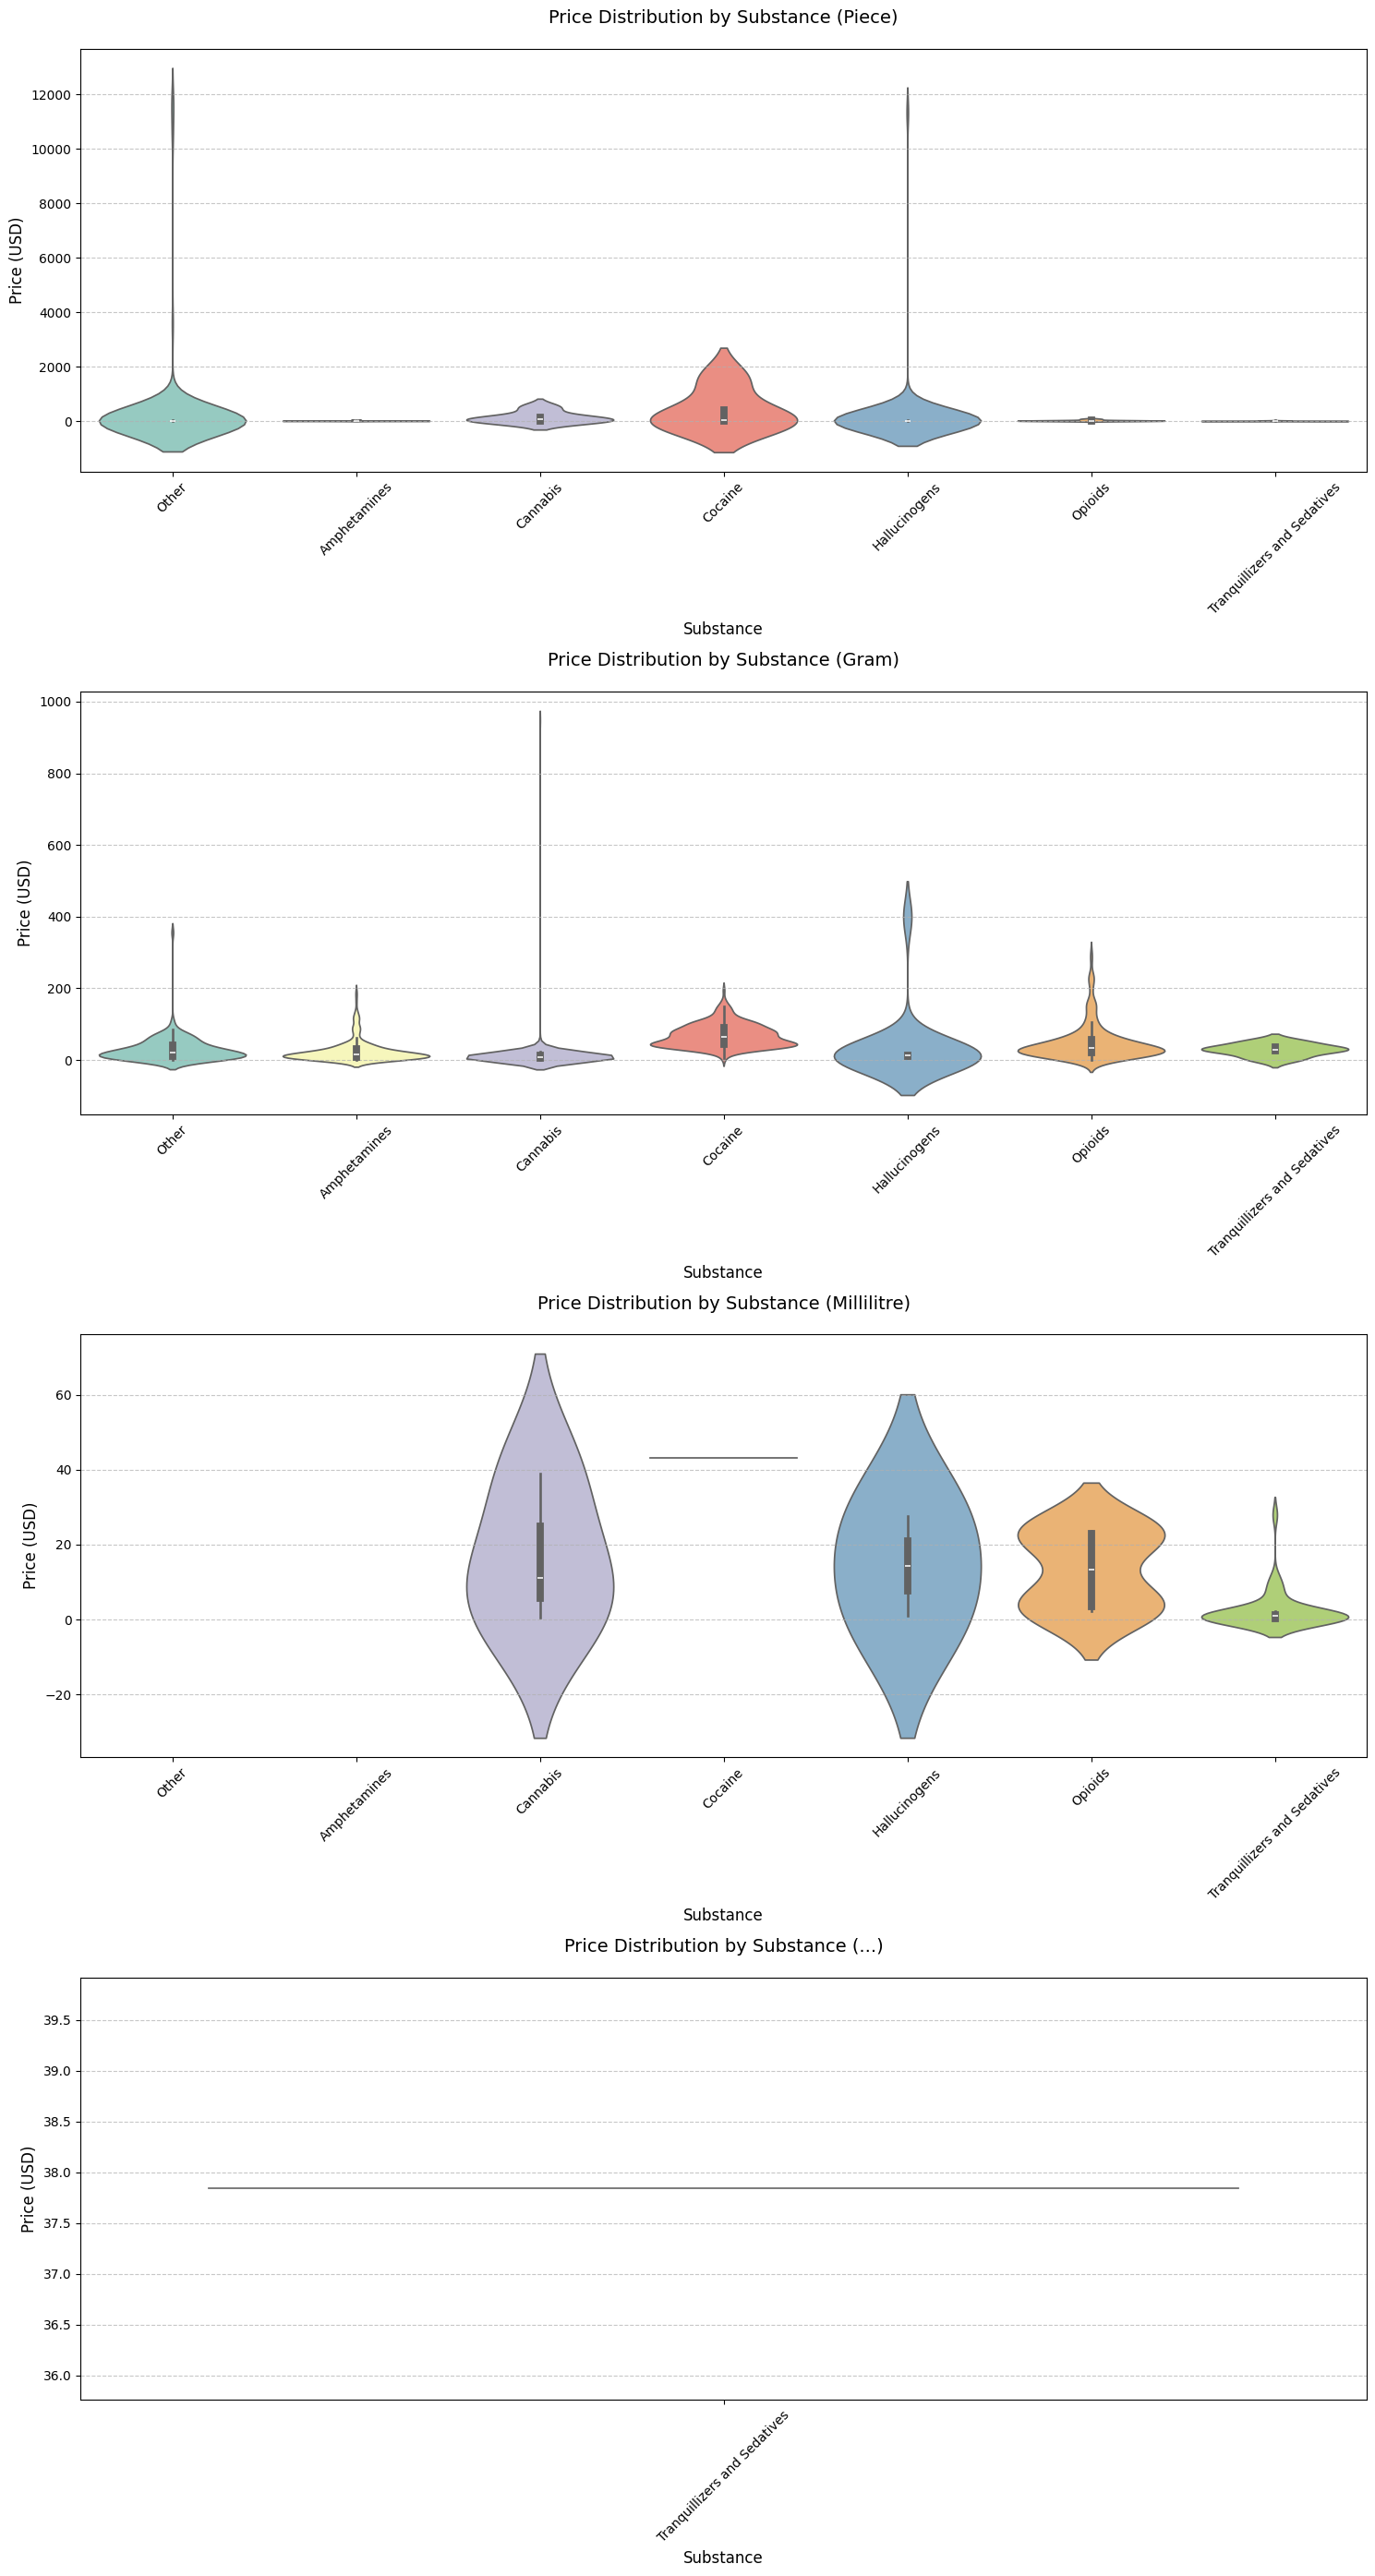

In [28]:
# Get unique units for subplot creation
units = drug_prices_df['Unit'].unique()
n_units = len(units)

# Create figure with subplots
fig, axes = plt.subplots(n_units, 1, figsize=(15, 7*n_units))

# Create a violin plot for each unit
for i, unit in enumerate(units):
    # Filter data for current unit
    unit_data = drug_prices_df[drug_prices_df['Unit'] == unit]
    
    # Create violin plot
    sns.violinplot(data=unit_data, 
                   x='Substance', 
                   y='Typical_USD',
                   hue='Substance',
                   legend=False,
                   ax=axes[i], 
                   palette='Set3',
                   inner='box')  # Shows box plot inside violin
    
    # Customize each subplot
    axes[i].set_title(f'Price Distribution by Substance ({unit})', fontsize=14, pad=20)
    axes[i].set_xlabel('Substance', fontsize=12)
    axes[i].set_ylabel('Price (USD)', fontsize=12)
    
    # Fix the rotation of x-axis labels
    plt.setp(axes[i].get_xticklabels(), rotation=45)
    
    axes[i].grid(True, axis='y', linestyle='--', alpha=0.7)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

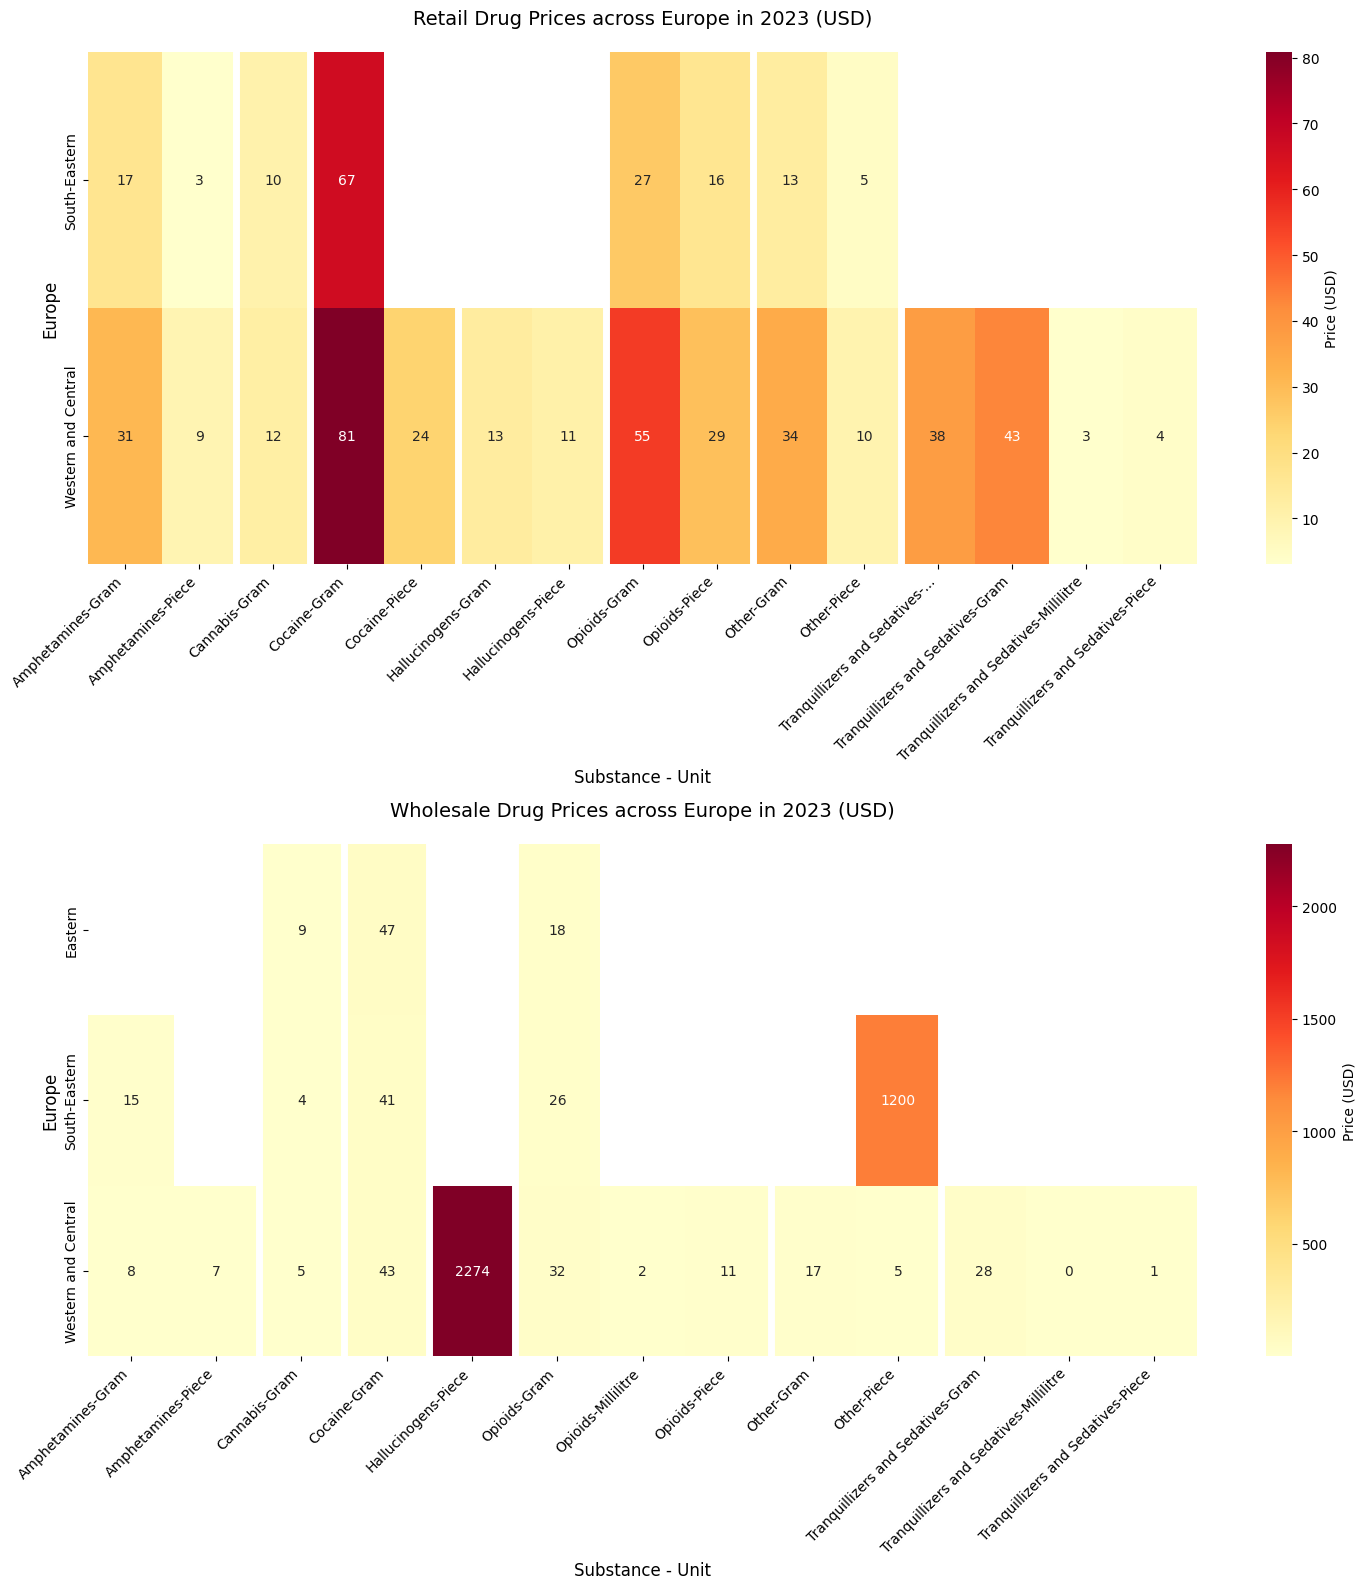

In [29]:
plot_df = drug_prices_df.copy()

latest_year = plot_df['Year'].max()
latest_data = plot_df[plot_df['Year'] == latest_year]

latest_data = plot_df[plot_df['Year'] == latest_year].copy()

latest_data['SubRegion'] = latest_data['SubRegion'].str.replace(' Europe', '')

retail_data = latest_data[latest_data['LevelOfSale'] == 'Retail'].pivot_table(
    values='Typical_USD',
    index='SubRegion',
    columns=['Substance', 'Unit'],
    aggfunc='mean'
)

wholesale_data = latest_data[latest_data['LevelOfSale'] == 'Wholesale'].pivot_table(
    values='Typical_USD',
    index='SubRegion',
    columns=['Substance', 'Unit'],
    aggfunc='mean'
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 16))

def create_heatmap(data, ax, title):
    sns.heatmap(data, annot=True, fmt='.0f', cmap='YlOrRd', 
                cbar_kws={'label': 'Price (USD)'}, ax=ax)
    
    substances = data.columns.get_level_values('Substance').unique()
    separators = np.cumsum([len(data.columns.get_level_values('Unit')[
        data.columns.get_level_values('Substance') == substance
    ]) for substance in substances])[:-1]
    
    for separator in separators:
        ax.axvline(x=separator, color='white', lw=5)
    
    ax.set_title(title, fontsize=14, pad=20)
    ax.set_xlabel('Substance - Unit', fontsize=12)
    ax.set_ylabel('Europe', fontsize=12)
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

create_heatmap(retail_data, ax1, f'Retail Drug Prices across Europe in {latest_year} (USD)')
create_heatmap(wholesale_data, ax2, f'Wholesale Drug Prices across Europe in {latest_year} (USD)')

plt.tight_layout()
plt.show()

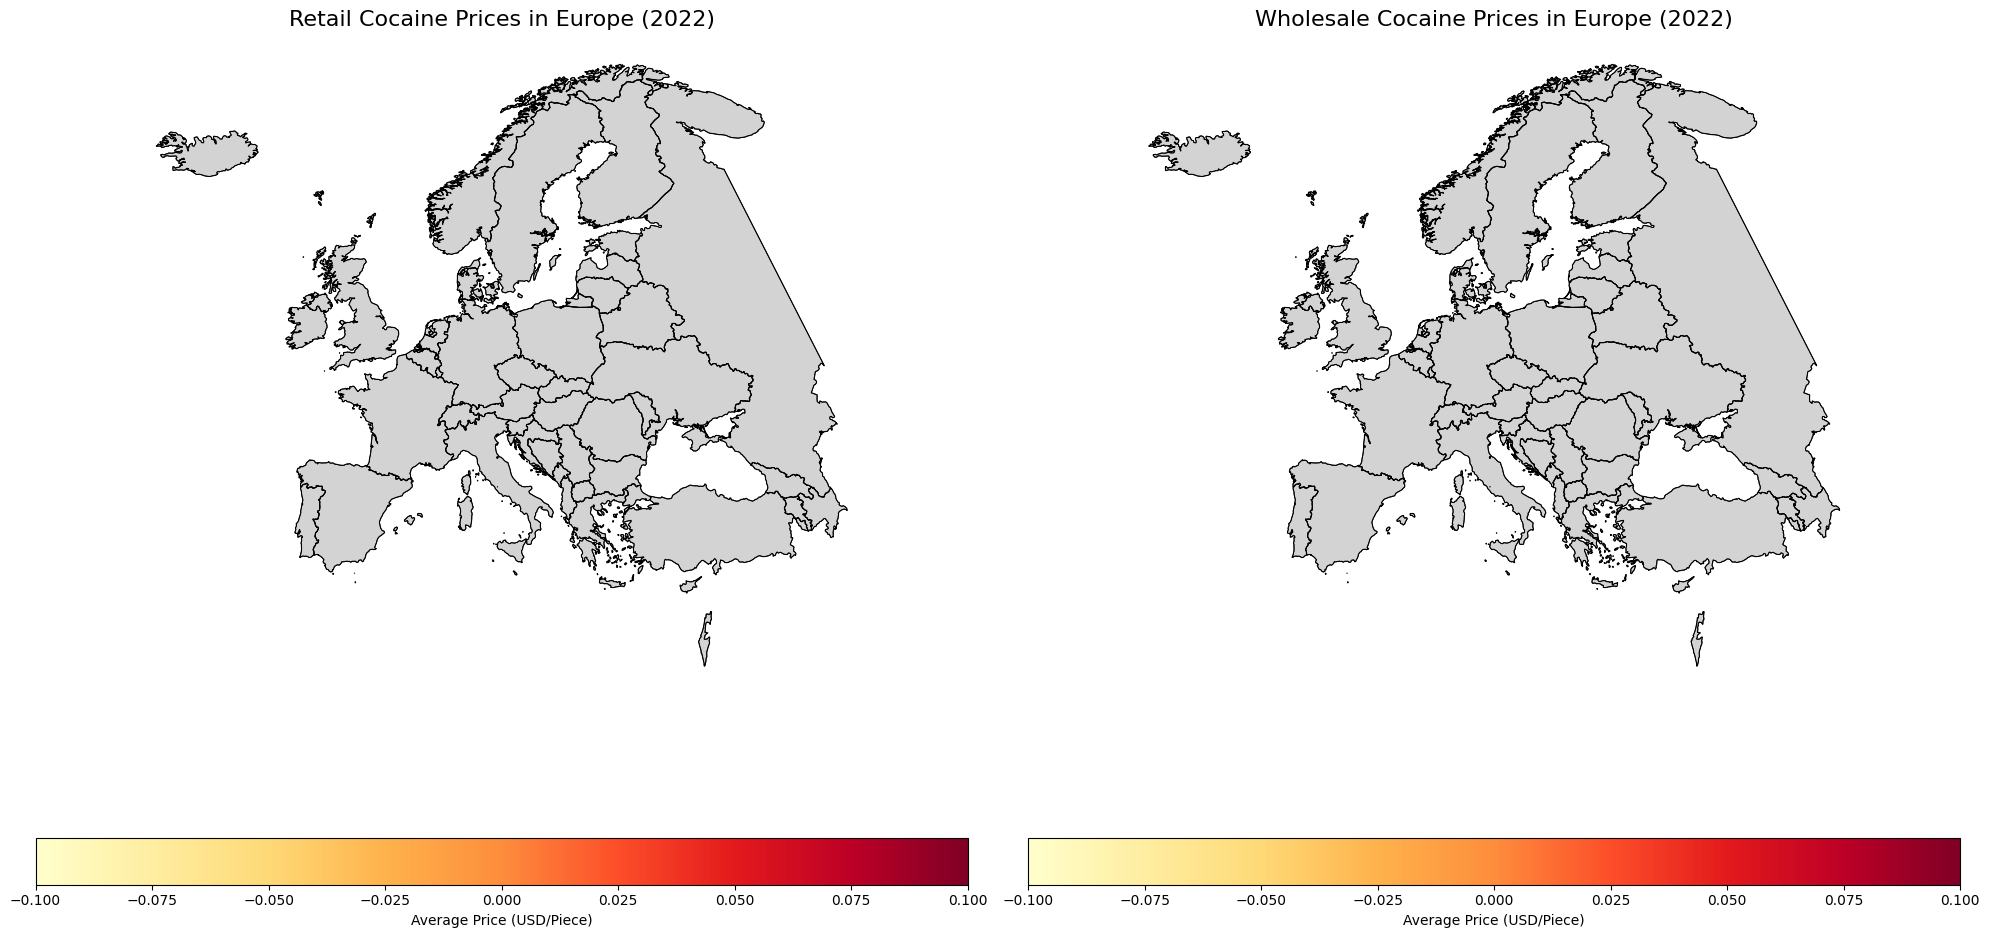

In [31]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests

# Load the GeoJSON file
url = "https://raw.githubusercontent.com/leakyMirror/map-of-europe/master/GeoJSON/europe.geojson"
response = requests.get(url)
europe_gdf = gpd.read_file(response.content)
drug = 'Cocaine'
unit = 'Piece'
year = 2022
plot_df = drug_prices_df.copy()
# Filter data for the year 2022
df_filtered = plot_df[(plot_df['Year'] == year) & (
    plot_df['Substance'] == drug) & (plot_df['Unit'] == unit)]

# Prepare data for Retail and Wholesale
retail_data = df_filtered[df_filtered['LevelOfSale'] == 'Retail'].groupby(
    'Country')['Typical_USD'].mean().reset_index()
wholesale_data = df_filtered[df_filtered['LevelOfSale'] == 'Wholesale'].groupby(
    'Country')['Typical_USD'].mean().reset_index()

# Merge GeoDataFrame with the price data
europe_retail = europe_gdf.merge(
    retail_data, how='left', left_on='NAME', right_on='Country')
europe_wholesale = europe_gdf.merge(
    wholesale_data, how='left', left_on='NAME', right_on='Country')

# Create the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Function to plot map


def plot_map(gdf, ax, title):
    gdf.plot(column='Typical_USD', ax=ax, legend=True,
             legend_kwds={
                 'label': f'Average Price (USD/{unit})', 'orientation': 'horizontal'},
             missing_kwds={'color': 'lightgrey'}, cmap='YlOrRd',
             edgecolor='black', linewidth=0.5)
    gdf.boundary.plot(ax=ax, color='black', linewidth=0.8)
    ax.axis('off')
    ax.set_title(title, fontsize=16)


# Plot Retail map
plot_map(europe_retail, ax1, f'Retail {drug} Prices in Europe ({year})')

# Plot Wholesale map
plot_map(europe_wholesale, ax2, f'Wholesale {drug} Prices in Europe ({year})')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

## Calculate the Spread

In [32]:
drug_prices_df['Spread_USD'] = drug_prices_df['Maximum_USD'] - drug_prices_df['Minimum_USD']
drug_prices_df['Spread_rel'] = drug_prices_df['Spread_USD'] / drug_prices_df['Typical_USD']

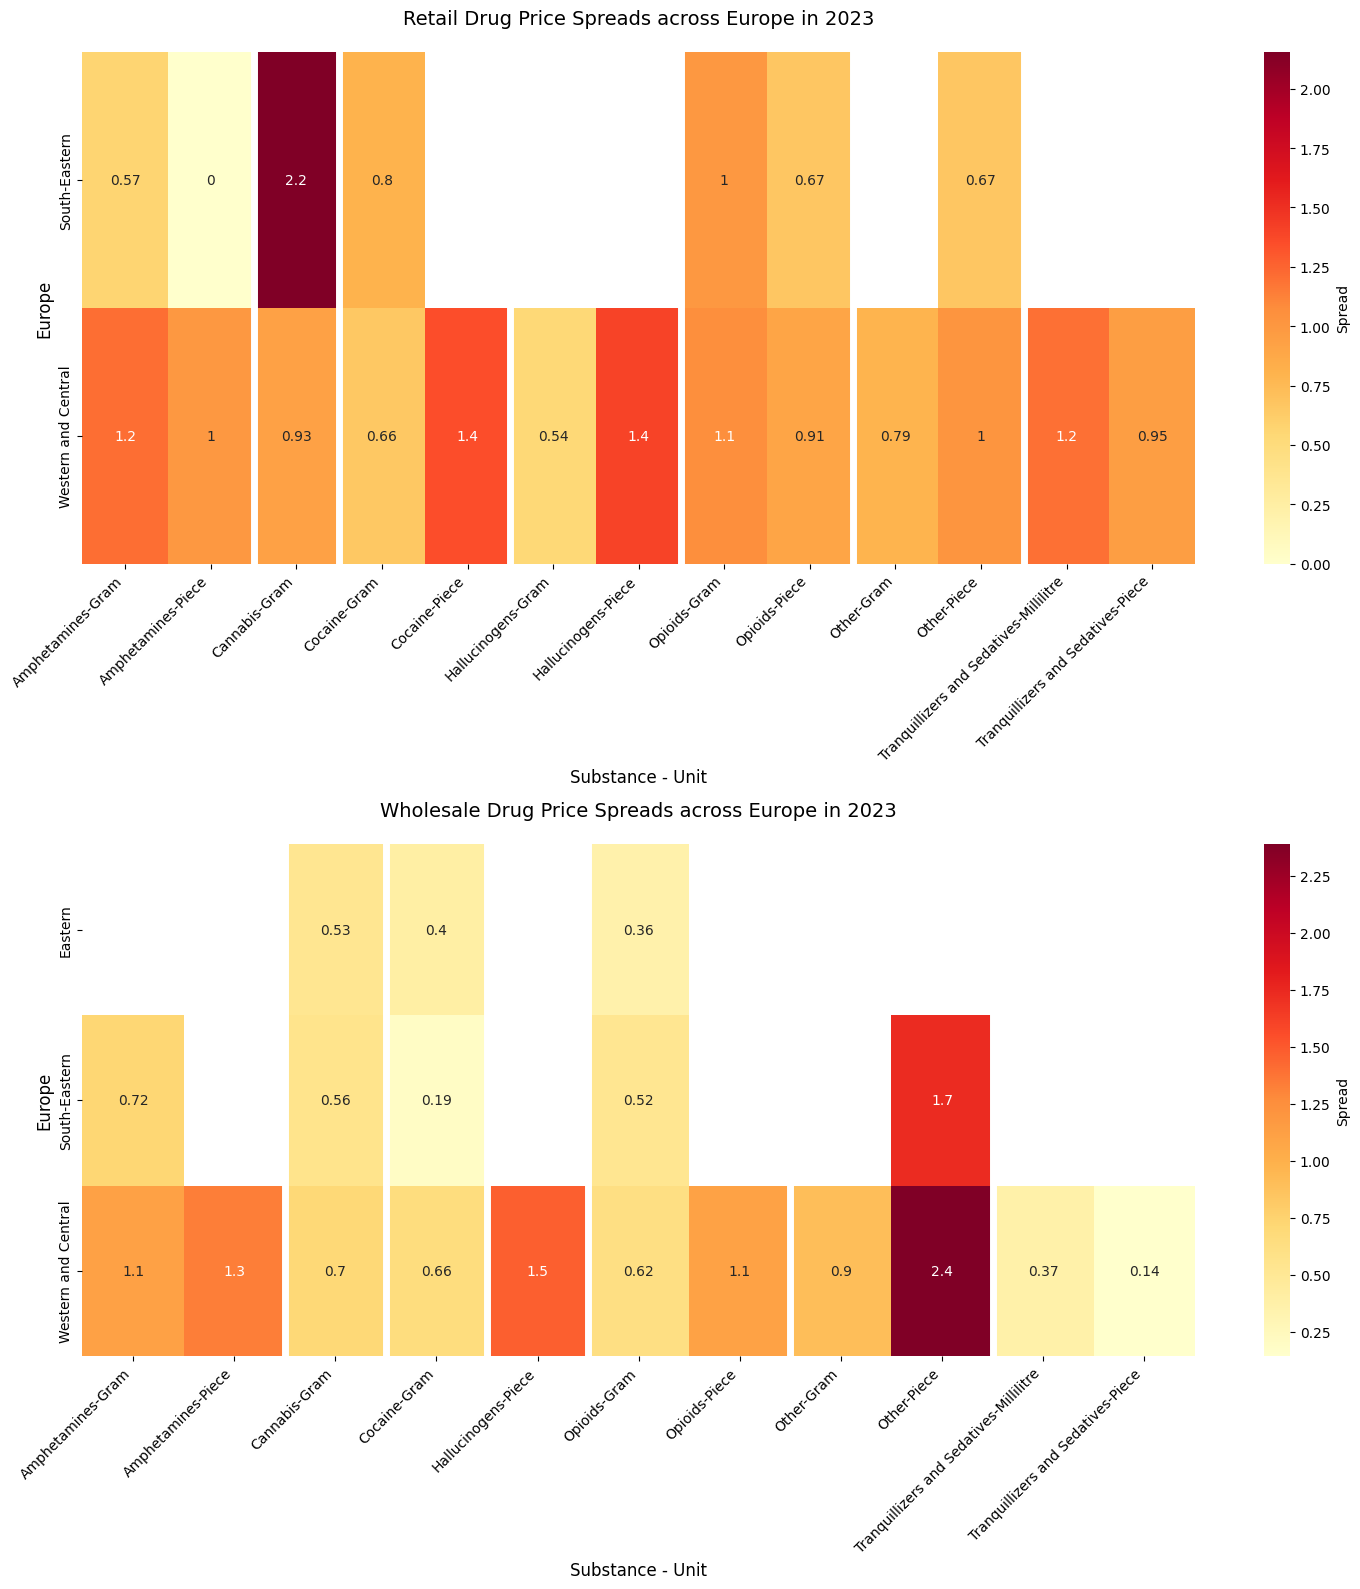

In [ ]:
plot_df = drug_prices_df.copy()

latest_year = plot_df['Year'].max()
latest_data = plot_df[plot_df['Year'] == latest_year]
latest_data = plot_df[plot_df['Year'] == latest_year].copy()
latest_data['SubRegion'] = latest_data['SubRegion'].str.replace(' Europe', '')

retail_data = latest_data[latest_data['LevelOfSale'] == 'Retail'].pivot_table(
    values='Spread_rel',
    index='SubRegion',
    columns=['Substance', 'Unit'],
    aggfunc='mean'
)

wholesale_data = latest_data[latest_data['LevelOfSale'] == 'Wholesale'].pivot_table(
    values='Spread_rel',
    index='SubRegion',
    columns=['Substance', 'Unit'],
    aggfunc='mean'
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 16))

def create_heatmap(data, ax, title):
    sns.heatmap(data, annot=True,  cmap='YlOrRd', 
                cbar_kws={'label': 'Spread'}, ax=ax)
    
    substances = data.columns.get_level_values('Substance').unique()
    separators = np.cumsum([len(data.columns.get_level_values('Unit')[
        data.columns.get_level_values('Substance') == substance
    ]) for substance in substances])[:-1]
    
    for separator in separators:
        ax.axvline(x=separator, color='white', lw=5)
    
    ax.set_title(title, fontsize=14, pad=20)
    ax.set_xlabel('Substance - Unit', fontsize=12)
    ax.set_ylabel('Europe', fontsize=12)
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

create_heatmap(retail_data, ax1, f'Retail Drug Price Spreads across Europe in {latest_year}')
create_heatmap(wholesale_data, ax2, f'Wholesale Drug Price Spreads across Europe in {latest_year}')

plt.tight_layout()
plt.show()

### Interpreting the Relative Spread:

- A higher relative spread indicates greater price variability relative to the typical price.
- A relative spread of 1 means the difference between the maximum and minimum is equal to the typical price.
- In the data, some drugs have a relative spread greater than 1, indicating high variability.

## Calculate the Inland Margin
calculate the margin if drugs are bought wholesale and sold retail in the same country

In [34]:
retail_df = drug_prices_df[drug_prices_df['LevelOfSale'] == 'Retail']
wholesale_df = drug_prices_df[drug_prices_df['LevelOfSale'] == 'Wholesale']

retail_prices = retail_df.groupby(['Country', 'Substance'])['Typical_USD'].mean().reset_index()
wholesale_prices = wholesale_df.groupby(['Country', 'Substance'])['Typical_USD'].mean().reset_index()

inland_margin = pd.merge(retail_prices, wholesale_prices, on=['Country', 'Substance'], how='inner', suffixes=('_Retail', '_Wholesale'))

inland_margin['Margin'] = inland_margin['Typical_USD_Retail'] - inland_margin['Typical_USD_Wholesale']
inland_margin['RelativeMargin'] = (inland_margin['Margin'] / inland_margin['Typical_USD_Wholesale']) * 100
inland_margin = inland_margin.dropna(subset='RelativeMargin')

inland_best_margin = inland_margin.loc[inland_margin.groupby('Country')['RelativeMargin'].idxmax()].reset_index(drop=True)
columns_to_display = ['Country', 'Substance', 'Typical_USD_Retail', 'Typical_USD_Wholesale', 'Margin', 'RelativeMargin']

display(inland_best_margin[columns_to_display])

,Country,Substance,Typical_USD_Retail,Typical_USD_Wholesale,Margin,RelativeMargin
0,Austria,Cannabis,11.619617,4.152366,7.467251,179.831245
1,Belarus,Opioids,146.666667,22.401862,124.264805,554.707494
2,Belgium,Tranquillizers and Sedatives,17.216590,0.243104,16.973486,6981.996932
3,Bosnia and Herzegovina,Opioids,26.516955,17.793594,8.723361,49.025290
4,Bulgaria,Cannabis,8.928043,4.020221,4.907822,122.078397
5,Croatia,Amphetamines,13.982426,2.417269,11.565158,478.439079
6,Czech Republic,Other,9.106975,3.083427,6.023548,195.352399
7,Denmark,Amphetamines,34.671145,3.286370,31.384775,954.998241
8,Estonia,Tranquillizers and Sedatives,11.514643,2.057403,9.457240,459.668719
9,Finland,Other,66.407731,7.077998,59.329733,838.227613


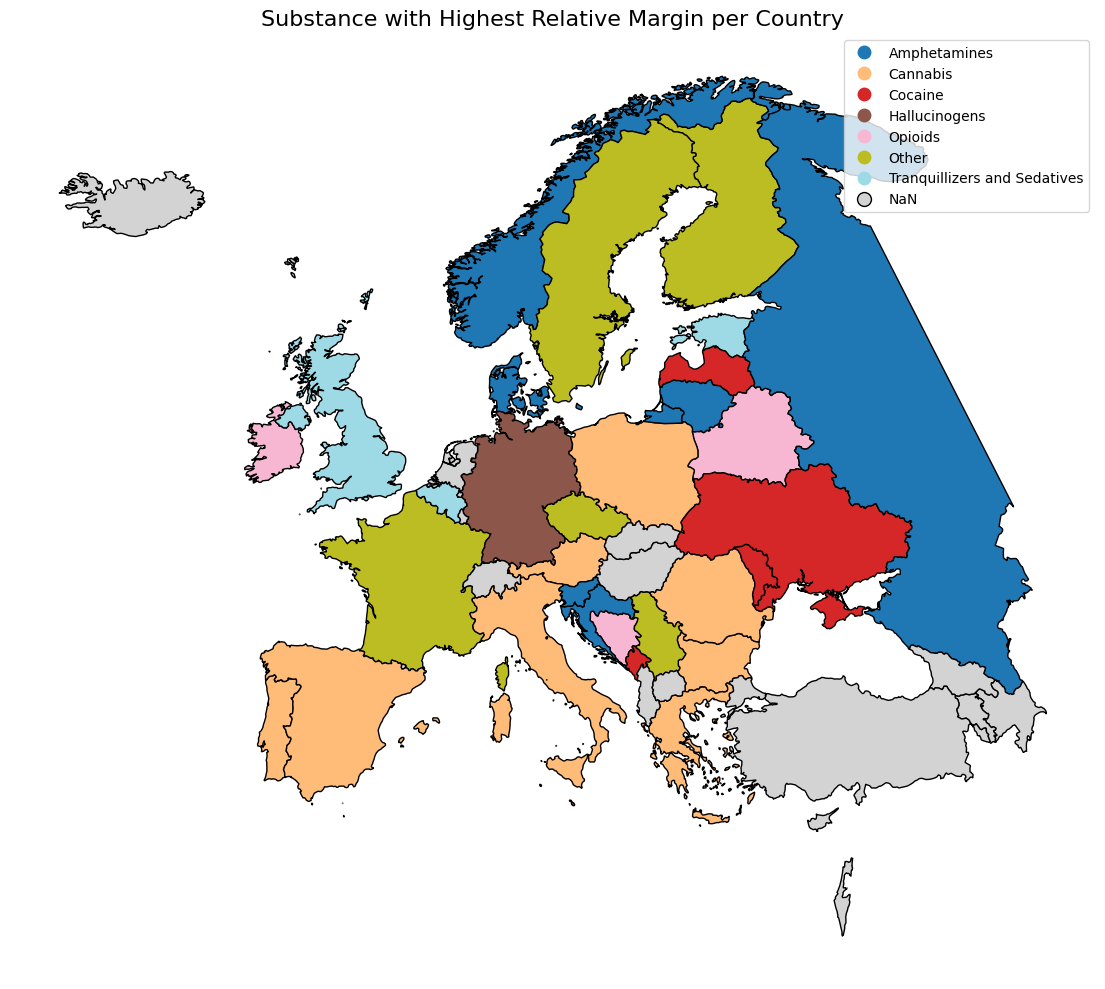

In [35]:
import matplotlib.patches as mpatches

url = "https://raw.githubusercontent.com/leakyMirror/map-of-europe/master/GeoJSON/europe.geojson"
response = requests.get(url)
europe_gdf = gpd.read_file(response.content)

map_df = europe_gdf.merge(inland_best_margin, how='left',
                          left_on='NAME', right_on='Country')

fig, ax = plt.subplots(1, 1, figsize=(15, 10))

map_df.plot(column='Substance', ax=ax, legend=True, cmap='tab20',
            missing_kwds={'color': 'lightgrey'}, edgecolor='black')

ax.axis('off')
ax.set_title('Substance with Highest Relative Margin per Country', fontsize=16)

plt.tight_layout()
plt.show()

## Purity

In [36]:
drug_purity_df.head()

,Region,SubRegion,Country,LevelOfSale,DrugGroup,Drug,Specify,Year,Typical,Minimum,Maximum,Measurement,Substance
0,Europe,Eastern Europe,Belarus,Retail,“Ecstasy”-type substances,MDMA,NaN,2021,97.0,95.0,98.0,% (percent),Other
1,Europe,Eastern Europe,Belarus,Retail,Amphetamine-type stimulants,Amphetamine powder,NaN,2021,97.0,95.0,98.0,% (percent),Amphetamines
2,Europe,Eastern Europe,Belarus,Retail,Amphetamine-type stimulants,Methamphetamine powder,NaN,2021,97.0,95.0,98.0,% (percent),Amphetamines
3,Europe,Eastern Europe,Belarus,Retail,Cannabis-type drugs,Cannabis herb (marijuana),NaN,2021,97.0,95.0,98.0,% (percent),Cannabis
4,Europe,Eastern Europe,Belarus,Retail,Cannabis-type drugs,Cannabis resin (hashish),NaN,2021,97.0,95.0,98.0,% (percent),Cannabis


In [37]:
drug_purity_df['Measurement'].unique()

array(['% (percent)', nan, 'mg/tablet', '...'], dtype=object)

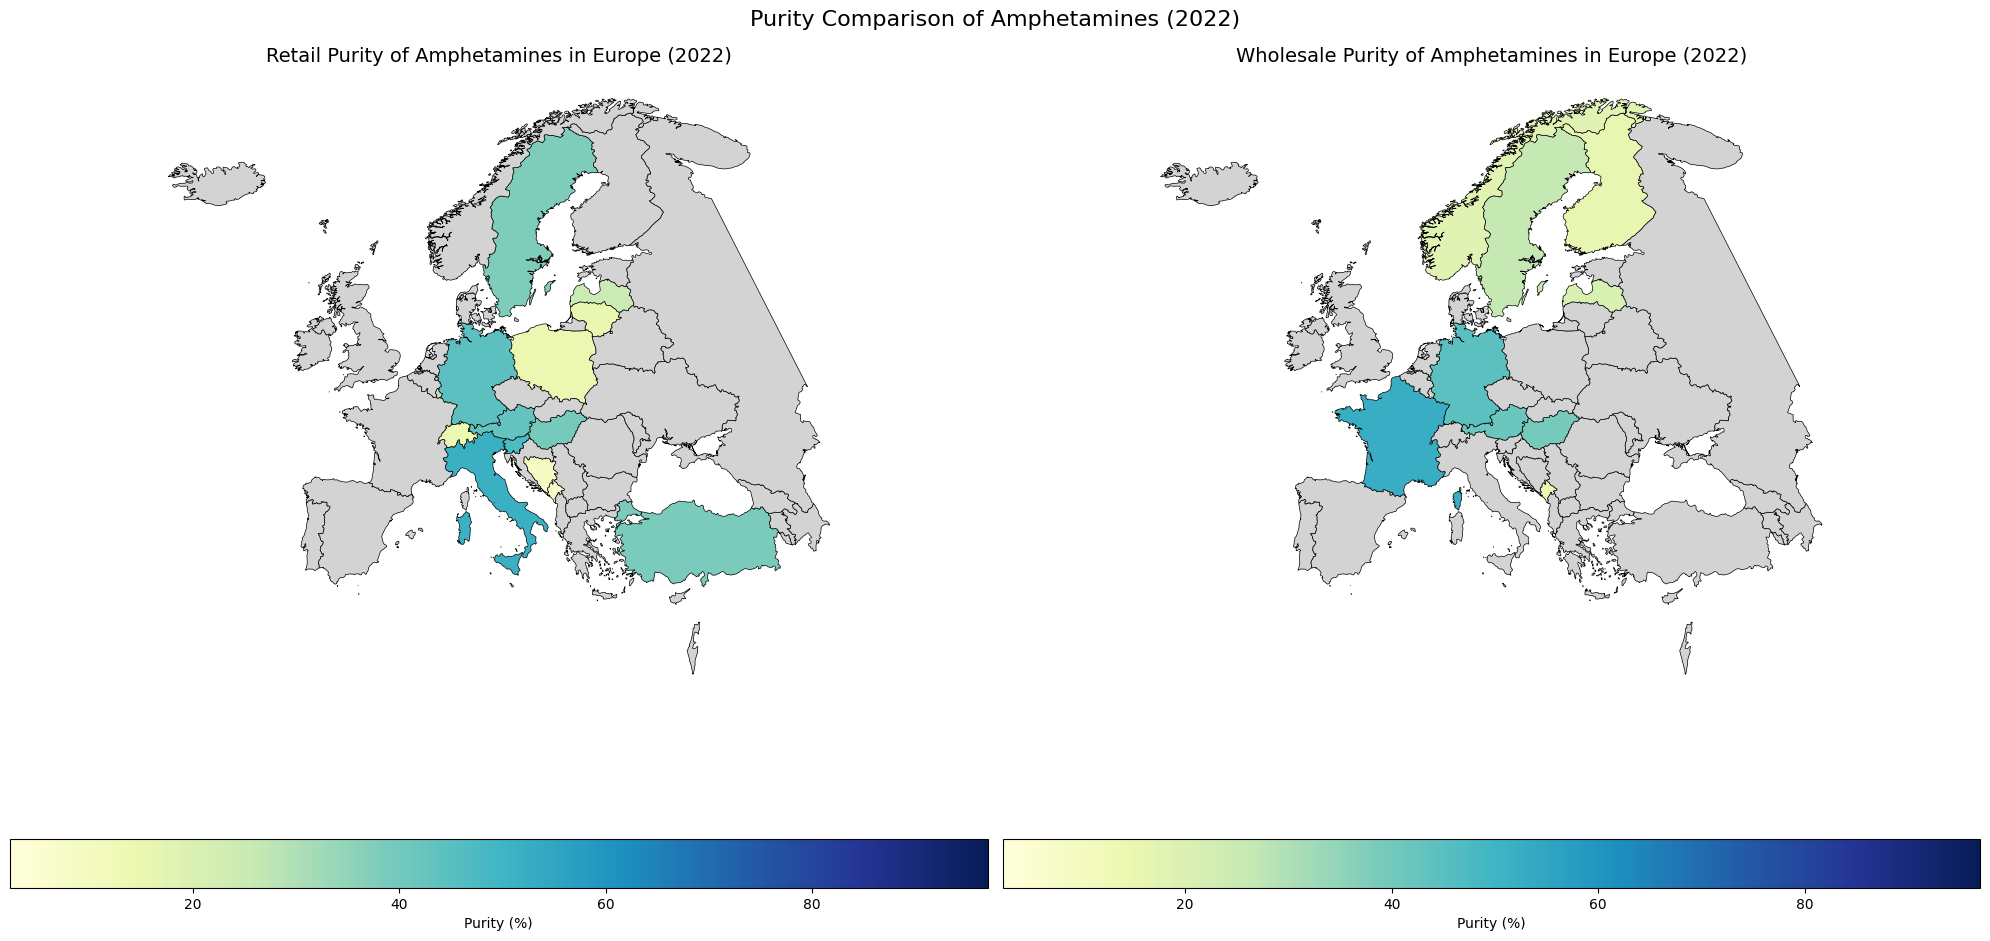

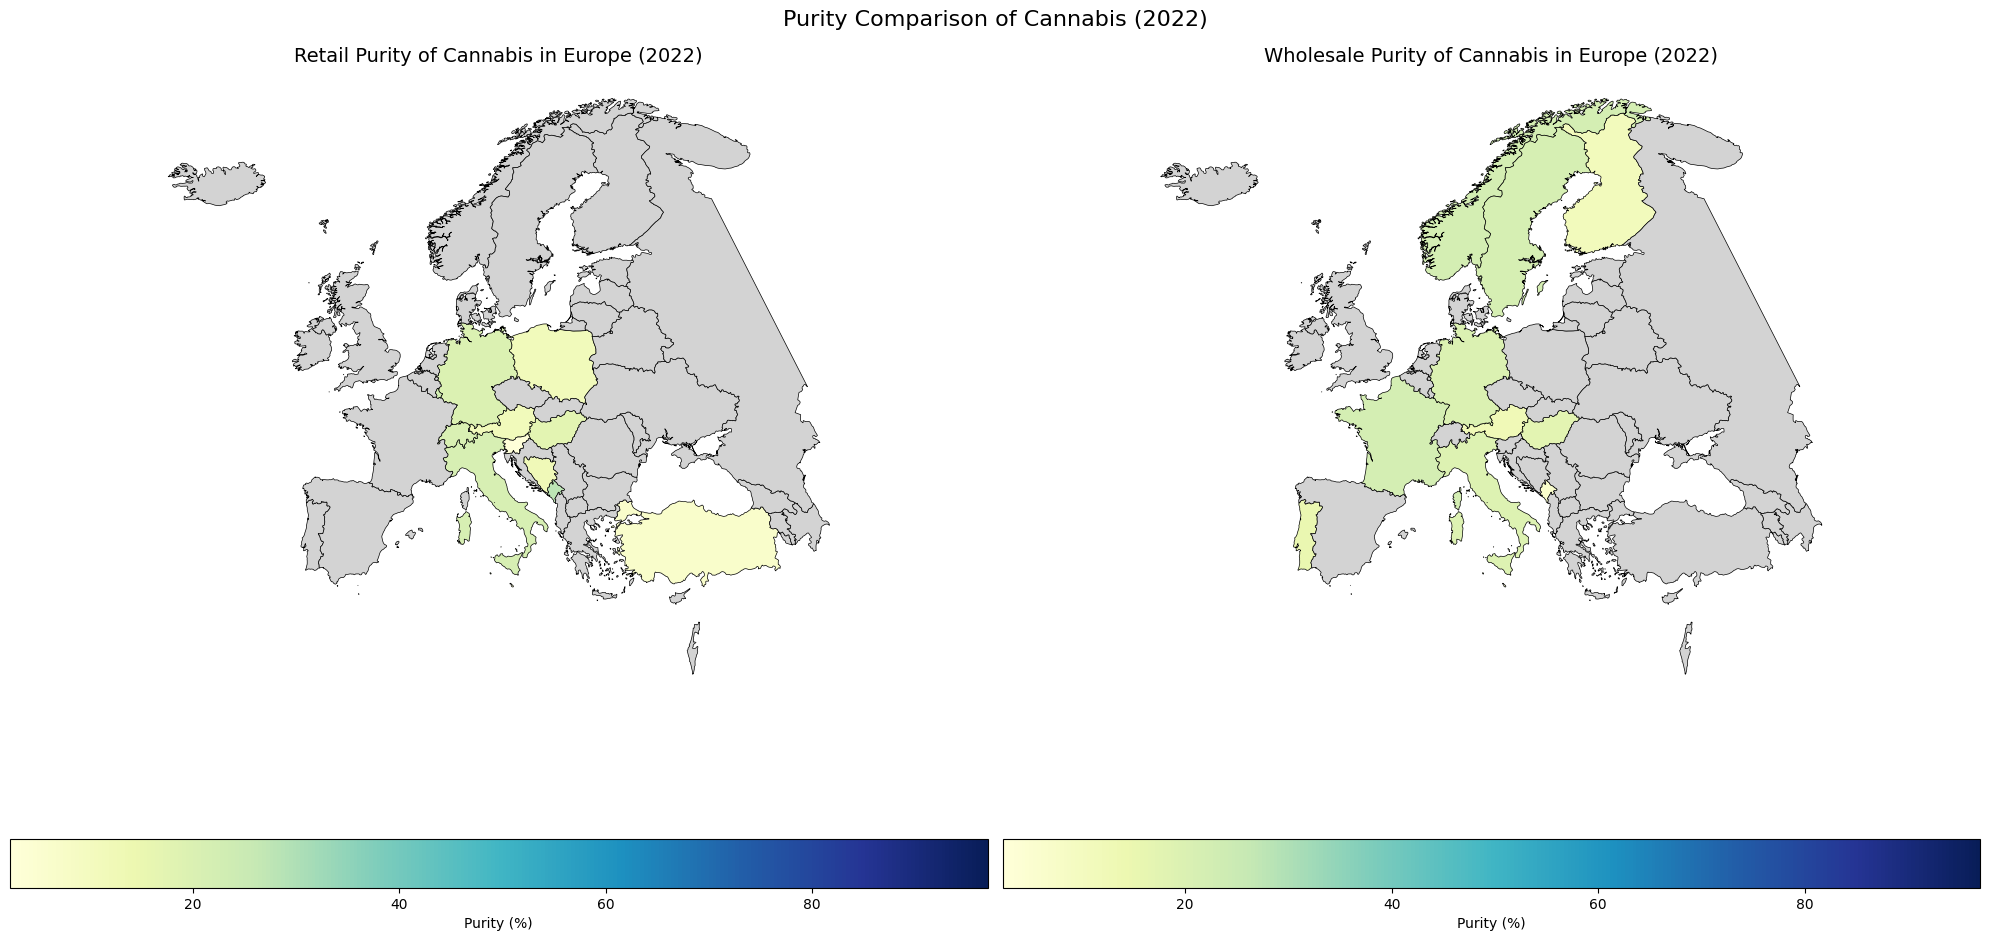

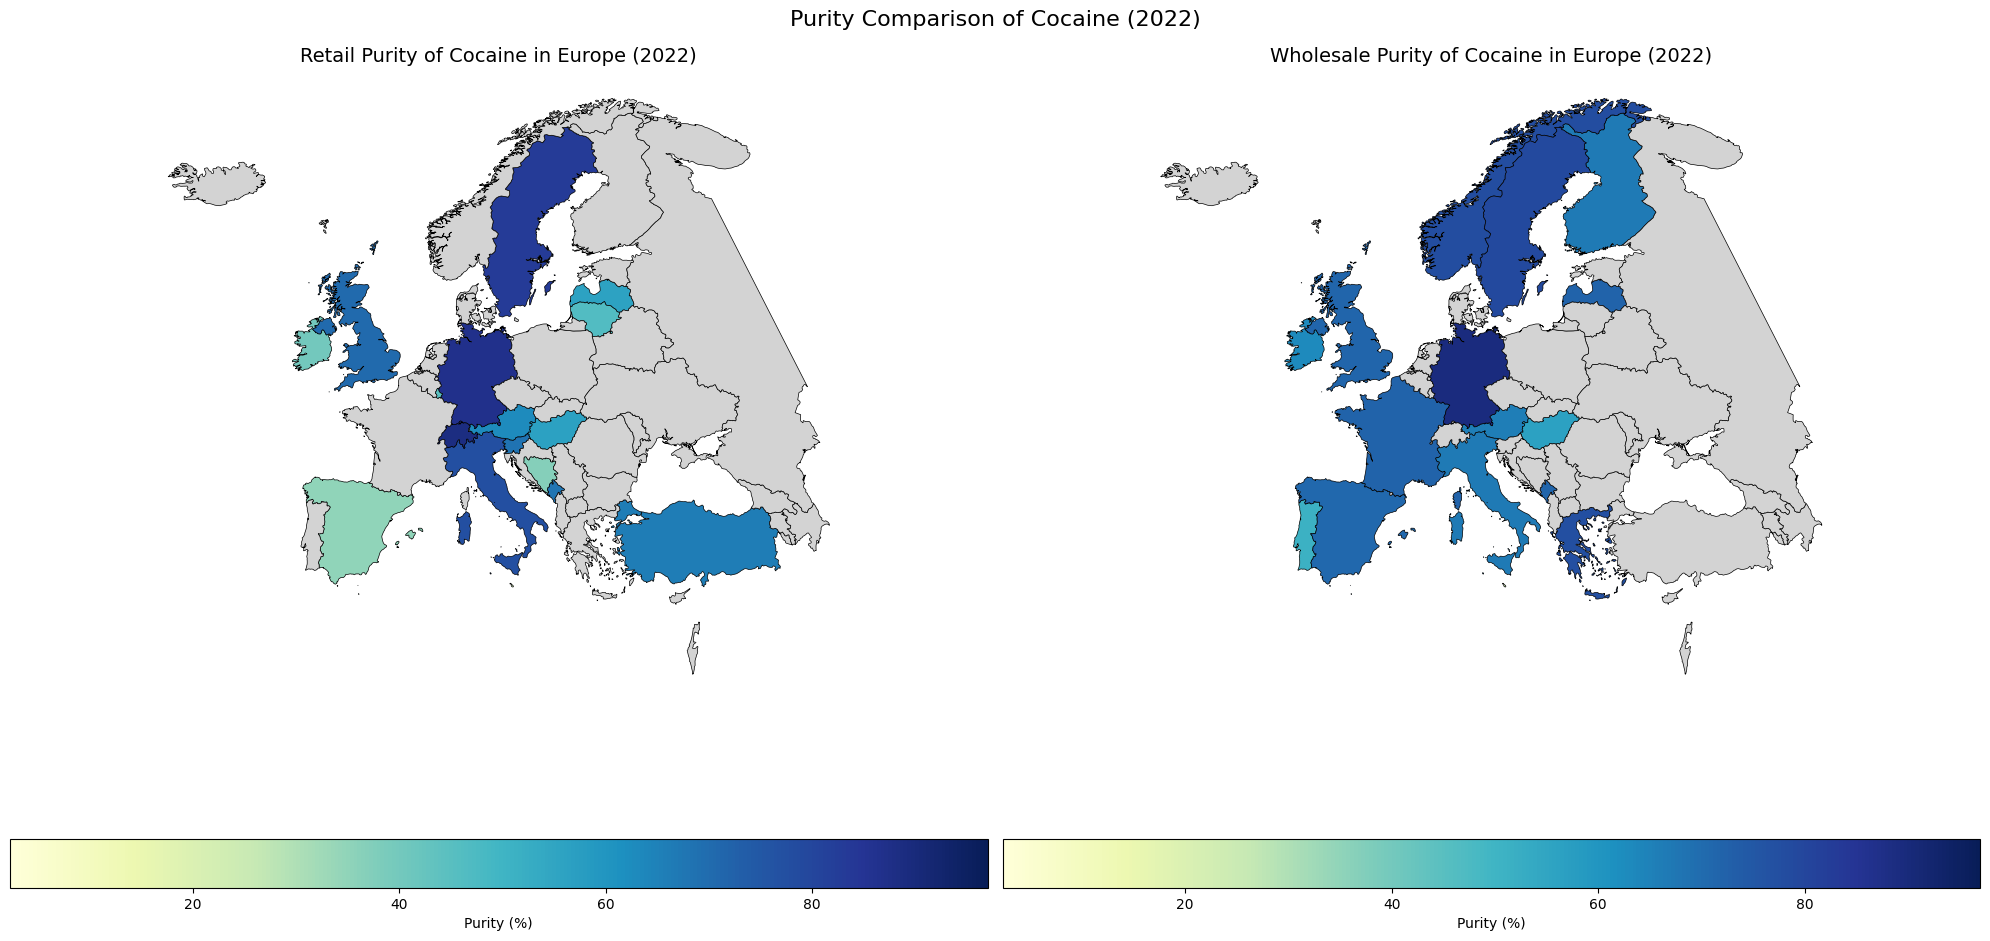

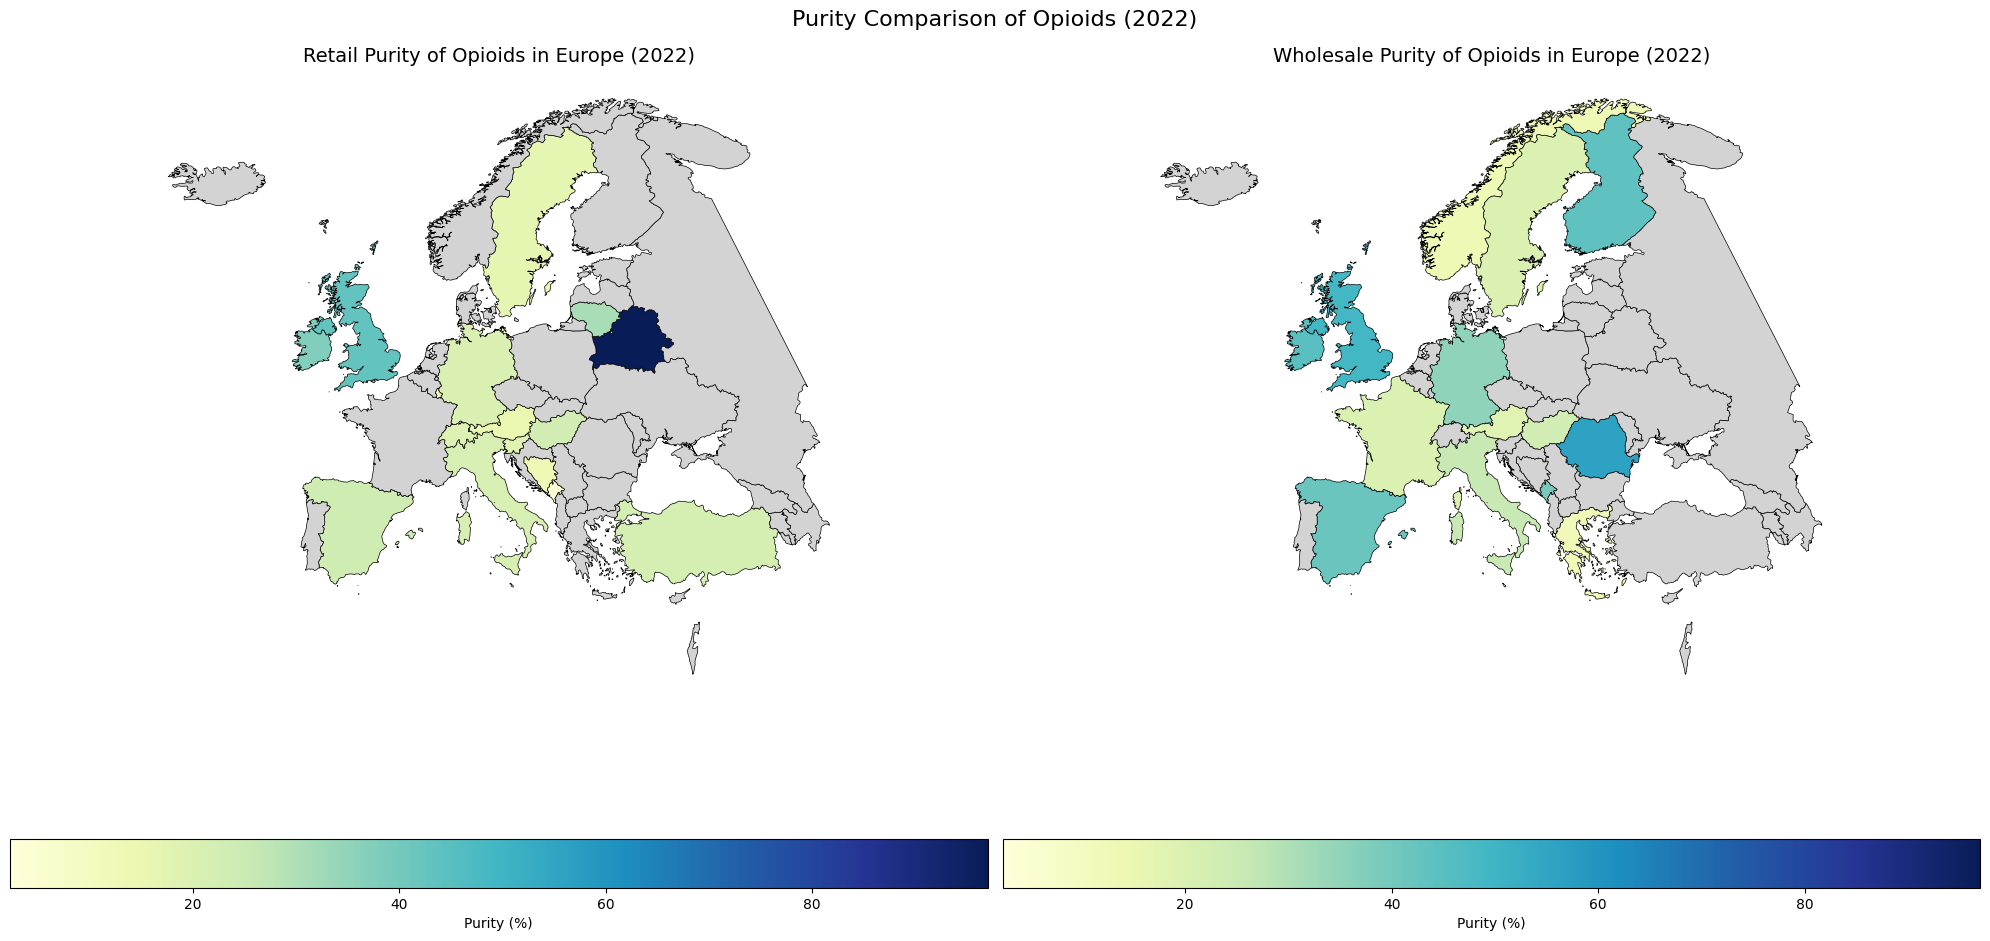

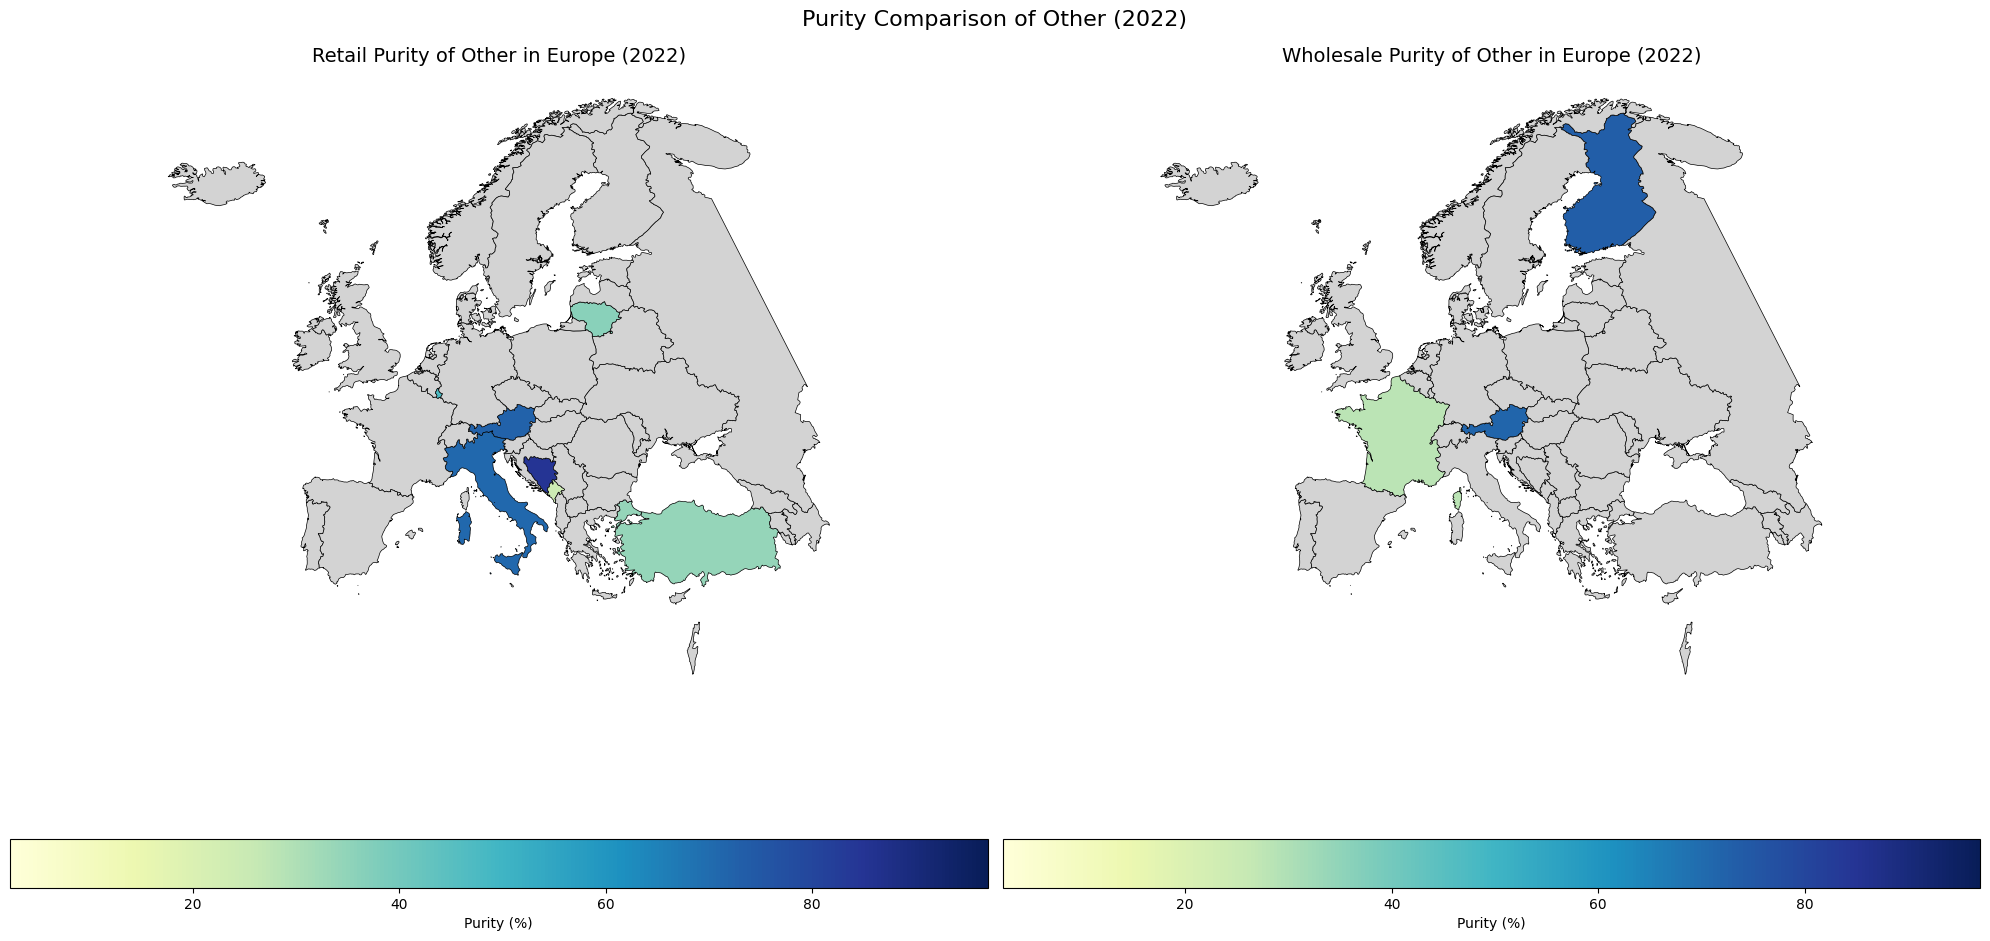

In [38]:
df_filtered = drug_purity_df[(drug_purity_df['Year'] == 2022)&(drug_purity_df['Measurement']=='% (percent)')]
purity_df = df_filtered.groupby(['Substance', 'LevelOfSale', 'Country'])['Typical'].mean().reset_index()


url = "https://raw.githubusercontent.com/leakyMirror/map-of-europe/master/GeoJSON/europe.geojson"
response = requests.get(url)
europe_gdf = gpd.read_file(response.content)

substances = purity_df['Substance'].unique()

for substance in substances:
    substance_df = purity_df[purity_df['Substance'] == substance]

    retail_data = substance_df[substance_df['LevelOfSale'] == 'Retail']
    wholesale_data = substance_df[substance_df['LevelOfSale'] == 'Wholesale']

    retail_map_df = europe_gdf.merge(retail_data, how='left', left_on='NAME', right_on='Country')
    wholesale_map_df = europe_gdf.merge(wholesale_data, how='left', left_on='NAME', right_on='Country')

    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    cmap = 'YlGnBu'

    vmin = min(purity_df['Typical'])
    vmax = max(purity_df['Typical'])

    ax1 = axes[0]
    retail_map_df.plot(column='Typical', ax=ax1, legend=True,
                        legend_kwds={'label': 'Purity (%)', 'orientation': 'horizontal'},
                        cmap=cmap, edgecolor='black', linewidth=0.5,
                        vmin=vmin, vmax=vmax,
                        missing_kwds={'color': 'lightgrey'})
    ax1.set_title(f'Retail Purity of {substance} in Europe (2022)', fontsize=14)
    ax1.axis('off')

    ax2 = axes[1]
    wholesale_map_df.plot(column='Typical', ax=ax2, legend=True,
                            legend_kwds={'label': 'Purity (%)', 'orientation': 'horizontal'},
                            cmap=cmap, edgecolor='black', linewidth=0.5,
                            vmin=vmin, vmax=vmax,
                            missing_kwds={'color': 'lightgrey'})
    ax2.set_title(f'Wholesale Purity of {substance} in Europe (2022)', fontsize=14)
    ax2.axis('off')

    fig.suptitle(f'Purity Comparison of {substance} (2022)', fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)

    plt.show()

## Seizures

In [39]:
drug_seizures_df.head()

,Region,SubRegion,Country,DrugGroup,DrugSubGroup,DrugName,Year,Kilograms,msCode,Substance
0,Europe,Eastern Europe,Belarus,“Ecstasy”-type substances,“Ecstasy”-type substances,"3,4-methylenedioxymethamphetamine (MDMA)",2020,0.142073,BLR,Other
1,Europe,Eastern Europe,Belarus,Amphetamine-type stimulants (excluding “ecstasy”),Amphetamine,Amphetamine,2020,0.002778,BLR,Other
2,Europe,Eastern Europe,Belarus,Amphetamine-type stimulants (excluding “ecstasy”),Methamphetamine,Methamphetamine,2020,0.142073,BLR,Other
3,Europe,Eastern Europe,Belarus,Cannabis-type drugs (excluding synthetic canna...,Cannabis herb (marijuana),Cannabis herb (marijuana),2020,102.488107,BLR,Cannabis
4,Europe,Eastern Europe,Belarus,Cannabis-type drugs (excluding synthetic canna...,Cannabis oil,Cannabis oil,2020,0.715323,BLR,Cannabis


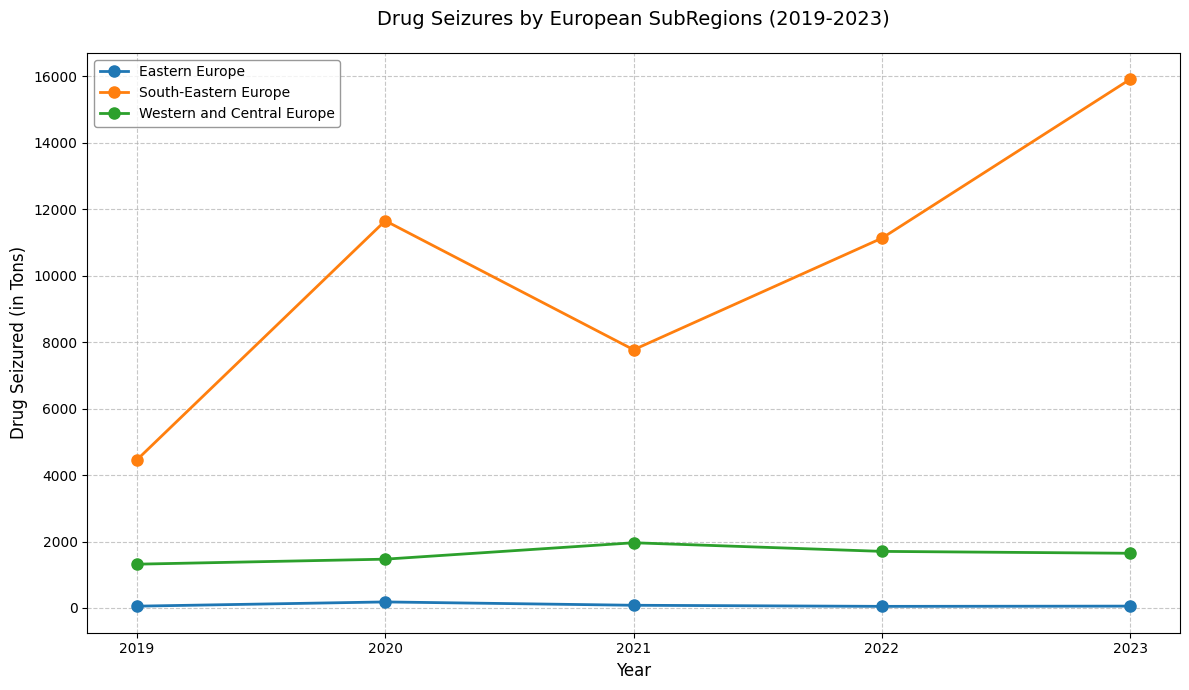

In [41]:
eu_seizures_per_subregion_and_year = drug_seizures_df[['SubRegion','Year','Kilograms']]
df_grouped = eu_seizures_per_subregion_and_year.groupby(['SubRegion', 'Year']).sum().reset_index()
# Convert Kilograms to Tons
df_grouped['Tons'] = df_grouped['Kilograms'] / 1000

# Pivot the data for easier plotting
df_pivot = df_grouped.pivot(index='Year', columns='SubRegion', values='Tons')

# Create the figure and axis
plt.figure(figsize=(12, 7))

# Plot lines with markers for each SubRegion
for column in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[column], marker='o', linewidth=2, markersize=8, label=column)

# Customize the plot
plt.title('Drug Seizures by European SubRegions (2019-2023)', fontsize=14, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Drug Seizured (in Tons)', fontsize=12)

# Add grid
plt.grid(True, linestyle='--', alpha=0.7)

# Set x-axis to show only integer years
plt.gca().xaxis.set_major_locator(plt.MultipleLocator(1))

# Customize legend
plt.legend(loc='upper left', fontsize=10, frameon=True, facecolor='white', edgecolor='gray')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

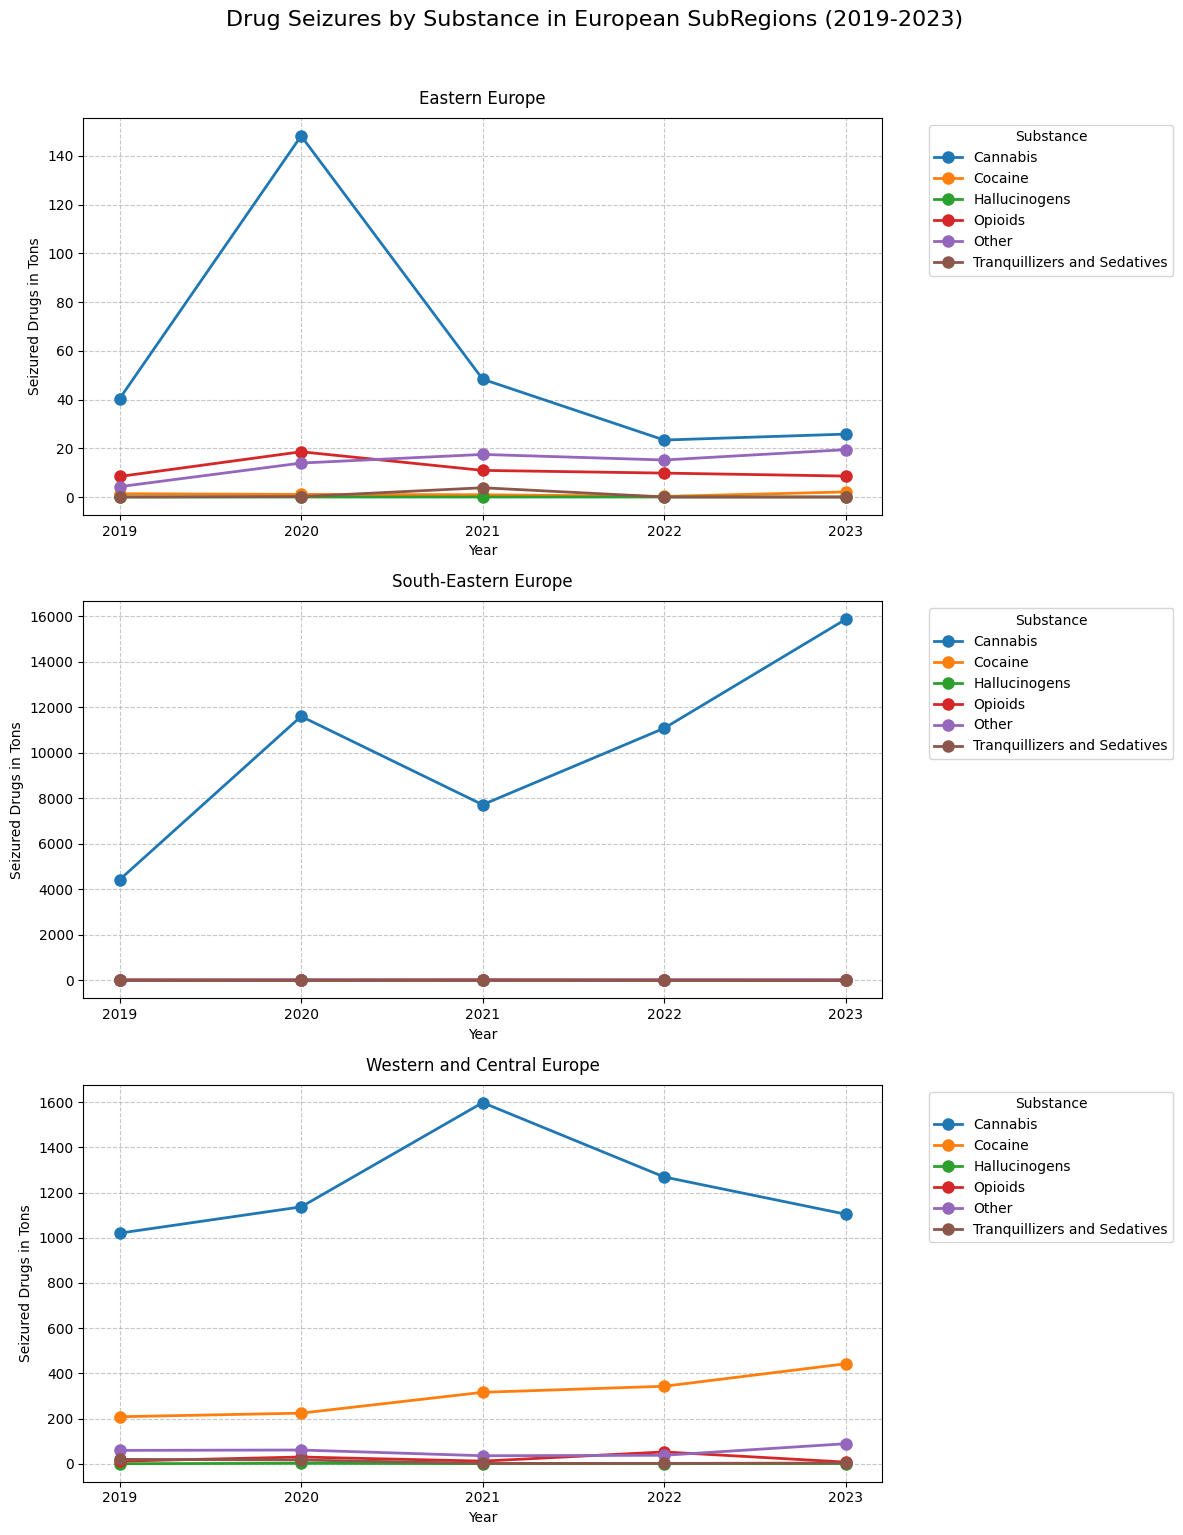

In [ ]:
df = drug_seizures_df[['SubRegion','Substance','Year','Kilograms']]
df_grouped = df.groupby(['SubRegion', 'Substance', 'Year']).sum().reset_index()

df_grouped['Tons'] = df_grouped['Kilograms'] / 1000
subregions = df_grouped['SubRegion'].unique()

fig, axes = plt.subplots(len(subregions), 1, figsize=(12, 5*len(subregions)))
fig.suptitle('Drug Seizures by Substance in European SubRegions (2019-2023)', fontsize=16, y=1.02)

colors = plt.cm.Set2(np.linspace(0, 1, len(df_grouped['Substance'].unique())))

for idx, subregion in enumerate(subregions):
    subregion_data = df_grouped[df_grouped['SubRegion'] == subregion]
    pivot_data = subregion_data.pivot(index='Year', columns='Substance', values='Tons')
    
    pivot_data.plot(marker='o', ax=axes[idx], linewidth=2, markersize=8)
    
    axes[idx].set_title(f'{subregion}', fontsize=12, pad=10)
    axes[idx].set_xlabel('Year', fontsize=10)
    axes[idx].set_ylabel('Seizured Drugs in Tons', fontsize=10)
    axes[idx].grid(True, linestyle='--', alpha=0.7)
    axes[idx].legend(title='Substance', bbox_to_anchor=(1.05, 1), loc='upper left')

    axes[idx].set_xticks(pivot_data.index)
    axes[idx].set_xticklabels(pivot_data.index.astype(int))


plt.tight_layout()
plt.show()

## Combine All Data

In [ ]:
# drug_seizures_df drug_prices_df drug_purity_df

In [44]:
drug_prices_join = drug_prices_df[drug_prices_df['Unit']=='Gram'].groupby(['SubRegion', 'Country', 'Substance', 'LevelOfSale', 'Year'], as_index=False)['Typical_USD'].mean()
drug_prices_join = drug_prices_join.set_index(['SubRegion', 'Country', 'Substance', 'Year'])

drug_purity_join = drug_purity_df[drug_purity_df['Measurement']=='% (percent)'].groupby(['SubRegion', 'Country', 'Substance', 'Year'], as_index=False)['Typical'].mean()
drug_purity_join = drug_purity_join.set_index(['SubRegion', 'Country', 'Substance', 'Year'])

drug_seizures_join = drug_seizures_df.groupby(['SubRegion', 'Country', 'Substance', 'Year'], as_index=False)['Kilograms'].sum()
drug_seizures_join = drug_seizures_join.set_index(['SubRegion', 'Country', 'Substance', 'Year'])

drug_data_combined =  drug_purity_join.join(drug_prices_join, how='inner')
drug_data_combined = drug_data_combined.join(drug_seizures_join, how='inner')

display(drug_data_combined)

Typical  \
SubRegion                  Country        Substance     Year            
Eastern Europe             Belarus        Cannabis      2021     97.0   
                                          Cocaine       2021     97.0   
                                          Hallucinogens 2021     97.0   
                                          Opioids       2021     97.0   
                                                        2022     97.0   
...                                                               ...   
Western and Central Europe United Kingdom Other         2019     74.0   
                                                        2020     78.5   
                                                        2020     78.5   
                                                        2021     80.0   
                                                        2021     80.0   

                                                             LevelOfSale  \
SubRegion                  Country        Substance     Year               
Eastern Europe             Belarus        Cannabis      2021      Retail   
                                          Cocaine       2021      Retail   
                                          Hallucinogens 2021      Retail   
                                          Opioids       2021      Retail   
                                                        2022      Retail   
...                                                                  ...   
Western and Central Europe United Kingdom Other         2019   Wholesale   
                                                        2020      Retail   
                                                        2020   Wholesale   
                                                        2021      Retail   
                                                        2021   Wholesale   

                                                              Typical_USD  \
SubRegion                  Country        Substance     Year                
Eastern Europe             Belarus        Cannabis      2021    40.000000   
                                          Cocaine       2021   150.000000   
                                          Hallucinogens 2021    12.000000   
                                          Opioids       2021   200.000000   
                                                        2022   200.000000   
...                                                                   ...   
Western and Central Europe United Kingdom Other         2019     8.269720   
                                                        2020    51.413882   
                                                        2020     3.856041   
                                                        2021    48.143054   
                                                        2021     9.628611   

                                                                Kilograms  
SubRegion                  Country        Substance     Year               
Eastern Europe             Belarus        Cannabis      2021    29.006000  
                                          Cocaine       2021     0.002030  
                                          Hallucinogens 2021     0.000003  
                                          Opioids       2021     0.406290  
                                                        2022     7.523800  
...                                                                   ...  
Western and Central Europe United Kingdom Other         2019  1172.000000  
                                                        2020  1049.321015  
                                                        2020  1049.321015  
                                                        2021   874.547250  
                                                        2021   874.547250  

[543 rows x 4 columns]

In [45]:
drug_data_combined.describe()

,Typical,Typical_USD,Kilograms
count,478.000000,449.000000,5.430000e+02
mean,39.685331,44.485993,8.739048e+04
std,25.263917,42.807286,9.809048e+05
min,2.300000,0.043243,0.000000e+00
25%,17.432500,11.727291,7.406446e+01
50%,32.617500,35.587189,6.775230e+02
75%,63.250000,64.864865,3.964938e+03
max,97.000000,355.871886,1.583367e+07


Not enough data to plot for substance: Amphetamines

Correlation coefficients for Cannabis:
Purity vs. Price: 0.30
Purity vs. Kilograms Seized: -0.17
Price vs. Kilograms Seized: -0.02


Correlation coefficients for Cocaine:
Purity vs. Price: 0.03
Purity vs. Kilograms Seized: 0.07
Price vs. Kilograms Seized: -0.22


Correlation coefficients for Opioids:
Purity vs. Price: 0.29
Purity vs. Kilograms Seized: 0.06
Price vs. Kilograms Seized: -0.12


Correlation coefficients for Other:
Purity vs. Price: 0.31
Purity vs. Kilograms Seized: -0.34
Price vs. Kilograms Seized: -0.09



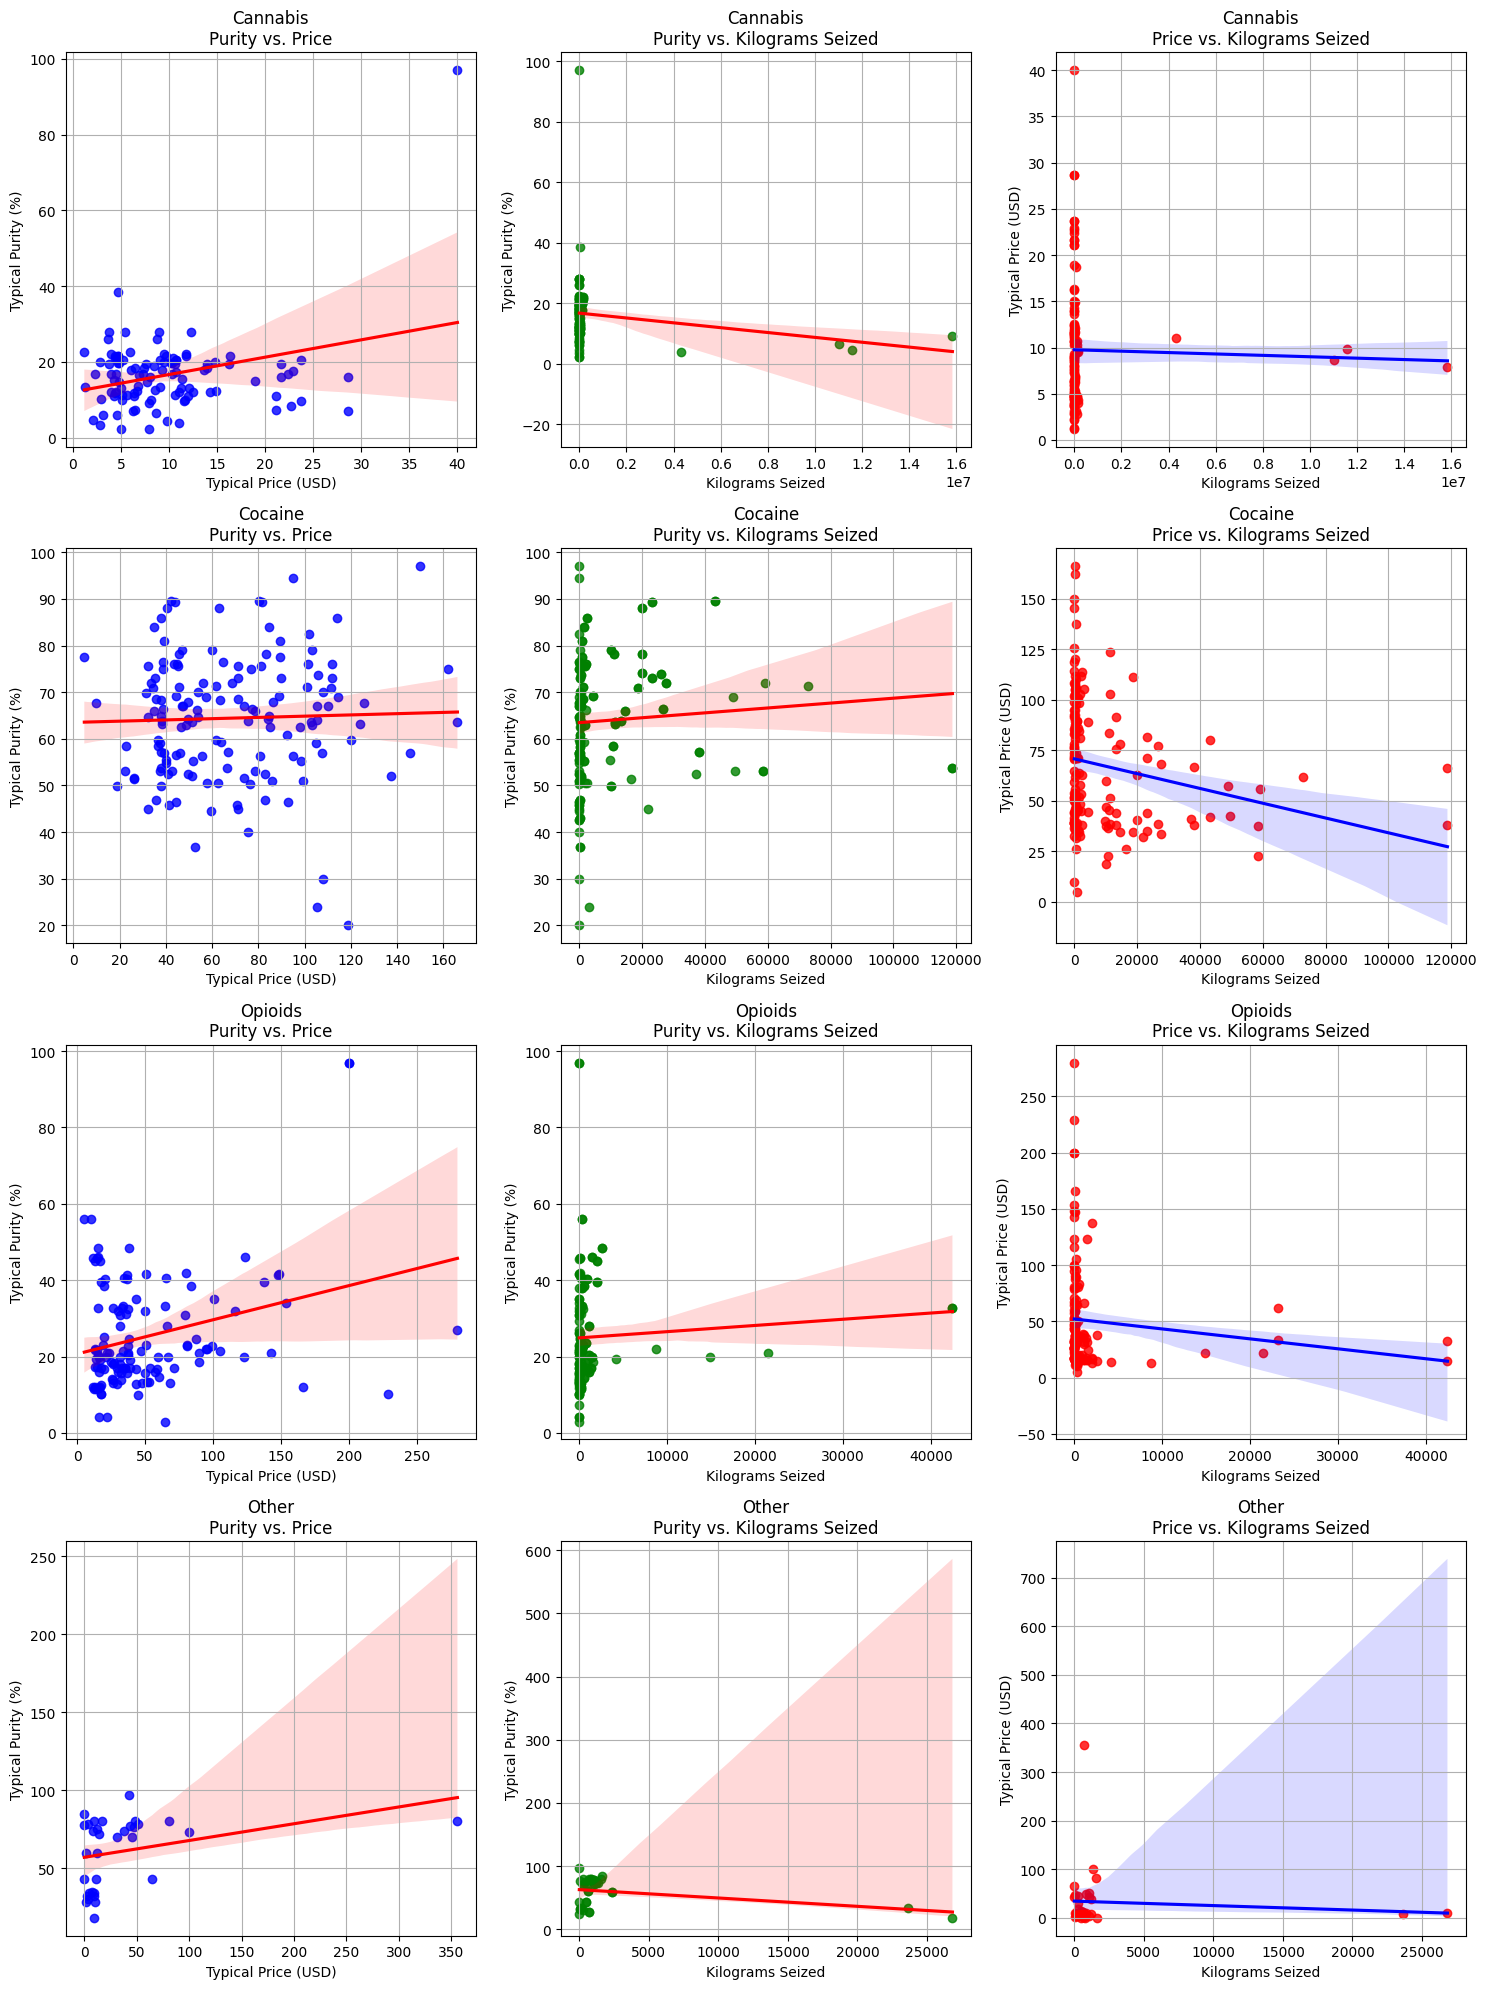

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


drug_data_combined = drug_data_combined.reset_index()

substances_to_plot = []
for substance in substances:
    subset = drug_data_combined[drug_data_combined['Substance'] == substance]
    if subset.shape[0] >= 2:
        substances_to_plot.append(substance)
    else:
        print(f"Not enough data to plot for substance: {substance}")


num_substances = len(substances_to_plot)
fig, axes = plt.subplots(num_substances, 3, figsize=(15, 5 * num_substances))

if num_substances == 1:
    axes = [axes]


for idx, substance in enumerate(substances_to_plot):
    subset = drug_data_combined[drug_data_combined['Substance'] == substance]
    
    # Purity vs. Price with Regression
    sns.regplot(
        ax=axes[idx][0],
        x='Typical_USD',
        y='Typical',
        data=subset,
        scatter_kws={'color': 'blue'},
        line_kws={'color': 'red'}
    )
    axes[idx][0].set_xlabel('Typical Price (USD)')
    axes[idx][0].set_ylabel('Typical Purity (%)')
    axes[idx][0].set_title(f'{substance}\nPurity vs. Price')
    axes[idx][0].grid(True)
    
    # Purity vs. Kilograms Seized with Regression
    sns.regplot(
        ax=axes[idx][1],
        x='Kilograms',
        y='Typical',
        data=subset,
        scatter_kws={'color': 'green'},
        line_kws={'color': 'red'}
    )
    axes[idx][1].set_xlabel('Kilograms Seized')
    axes[idx][1].set_ylabel('Typical Purity (%)')
    axes[idx][1].set_title(f'{substance}\nPurity vs. Kilograms Seized')
    axes[idx][1].grid(True)
    
    # Price vs. Kilograms Seized with Regression
    sns.regplot(
        ax=axes[idx][2],
        x='Kilograms',
        y='Typical_USD',
        data=subset,
        scatter_kws={'color': 'red'},
        line_kws={'color': 'blue'}
    )
    axes[idx][2].set_xlabel('Kilograms Seized')
    axes[idx][2].set_ylabel('Typical Price (USD)')
    axes[idx][2].set_title(f'{substance}\nPrice vs. Kilograms Seized')
    axes[idx][2].grid(True)
    

    corr_purity_price = subset['Typical_USD'].corr(subset['Typical'])
    corr_purity_kilograms = subset['Kilograms'].corr(subset['Typical'])
    corr_price_kilograms = subset['Kilograms'].corr(subset['Typical_USD'])
    
    print(f"\nCorrelation coefficients for {substance}:")
    print(f"Purity vs. Price: {corr_purity_price:.2f}")
    print(f"Purity vs. Kilograms Seized: {corr_purity_kilograms:.2f}")
    print(f"Price vs. Kilograms Seized: {corr_price_kilograms:.2f}\n")


plt.tight_layout()
plt.show()